In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [15]:
btc_holding = pd.read_csv('btc-holdings-over-time.csv')
btc = yf.download('BTC-USD', start='2020-08-09', end='2022-08-09')['Close'].squeeze()
mstr = yf.download('MSTR', start='2020-08-09', end='2022-08-09')['Close'].squeeze()
btc_holding = btc_holding.rename(columns={'DateTime': 'date', 'BTC holdings': 'btc_held'})

print(btc_holding.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  date  btc_held
0  2020-08-10 16:11:41     21454
1  2020-09-11 16:11:41     38250
2  2020-12-03 16:11:41     40824
3  2020-12-18 16:11:41     70470
4  2021-01-21 16:11:41     70784


In [8]:
import yfinance as yf
import pandas as pd

mstr = yf.Ticker('MSTR')

# Full historical shares outstanding time series
shares_ts = mstr.get_shares_full(start='2020-08-09', end='2022-08-09')
shares_ts = pd.DataFrame(shares_ts).reset_index()
shares_ts.columns = ['date', 'shares_outstanding']
shares_ts['date'] = pd.to_datetime(shares_ts['date']).dt.tz_localize(None)

print(shares_ts)

         date  shares_outstanding
0  2020-08-28             9686180
1  2020-09-05             9686180
2  2020-10-01             9630210
3  2020-10-01             9686180
4  2020-10-29             9686180
..        ...                 ...
64 2022-07-29            11871000
65 2022-07-30            11297500
66 2022-08-04            10021900
67 2022-08-05            11460600
68 2022-08-07            11300900

[69 rows x 2 columns]


In [18]:
import pandas as pd
import yfinance as yf

# ── Raw data ──────────────────────────────────────────────────────────────────
btc_raw  = yf.download('BTC-USD', start='2020-08-09', end='2022-08-09')['Close'].squeeze()
mstr_raw = yf.download('MSTR',    start='2020-08-09', end='2022-08-09')['Close'].squeeze()
holding_raw = pd.read_csv('btc-holdings-over-time.csv')

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start='2020-08-09', end='2022-08-09')

# ── 1. Daily spine ────────────────────────────────────────────────────────────
df = pd.DataFrame({'btc': btc_raw, 'mstr': mstr_raw})
df.index = pd.to_datetime(df.index).tz_localize(None)

# ── 2. BTC held ───────────────────────────────────────────────────────────────
holding = holding_raw.copy()
holding['date'] = pd.to_datetime(holding['DateTime'])
holding = holding.set_index('date')['BTC holdings'].rename('btc_held')
df = df.join(holding, how='left')
df['btc_held'] = df['btc_held'].ffill()

# ── 3. Shares outstanding ─────────────────────────────────────────────────────
shares = pd.Series(shares_raw)
shares.index = pd.to_datetime(shares.index).tz_localize(None)
shares.name = 'shares_outstanding'
df = df.join(shares, how='left')
df['shares_outstanding'] = df['shares_outstanding'].ffill()

# ── 4. Clean ──────────────────────────────────────────────────────────────────
df = df.dropna()

print(df.head(10))
print(f"\nShape: {df.shape}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Empty DataFrame
Columns: [btc, mstr, btc_held, shares_outstanding]
Index: []

Shape: (0, 4)


In [113]:
import pandas as pd
import yfinance as yf

# ── Raw data ──────────────────────────────────────────────────────────────────
START, END = '2021-02-01', '2023-01-01'

btc_raw  = yf.download('BTC-USD', start=START, end=END, progress=False)['Close']['BTC-USD']
mstr_raw = yf.download('MSTR',    start=START, end=END, progress=False)['Close']['MSTR']
holding_raw = pd.read_csv('btc-holdings-over-time.csv')

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)

# ── Flatten indexes ───────────────────────────────────────────────────────────
btc_raw.index  = pd.to_datetime(btc_raw.index).tz_localize(None)
mstr_raw.index = pd.to_datetime(mstr_raw.index).tz_localize(None)

# ── 1. Daily spine ────────────────────────────────────────────────────────────
df = pd.DataFrame({'btc': btc_raw, 'mstr': mstr_raw})

# ── 2. BTC held ───────────────────────────────────────────────────────────────
holding = holding_raw.copy()
holding['date'] = pd.to_datetime(holding['DateTime']).dt.tz_localize(None)
holding = holding.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.resample('D').last()  # snap to daily, keep last value per day
df = df.join(holding, how='left')
df['btc_held'] = df['btc_held'].ffill()

# ── 3. Shares outstanding ─────────────────────────────────────────────────────
shares = pd.Series(shares_raw)
shares.index = pd.to_datetime(shares.index).tz_localize(None)
shares.name = 'shares_outstanding'

# Clean noisy readings (drop values >2x local median)
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2]
shares = shares.resample('D').last()

df = df.join(shares, how='left')
df['shares_outstanding'] = df['shares_outstanding'].ffill()

# ── 4. Clean ──────────────────────────────────────────────────────────────────
df = df.dropna()

print(df.head(10))
print(f"\nShape: {df.shape}")

                     btc       mstr  btc_held  shares_outstanding
Date                                                             
2021-02-19  55888.132812  96.372002   71079.0           9587020.0
2021-02-22  54207.320312  87.599998   71079.0           9587020.0
2021-02-23  48824.425781  69.123001   90531.0           9587020.0
2021-02-24  49705.332031  81.768997   90531.0           9587020.0
2021-02-25  47093.851562  73.161003   90531.0           9587020.0
2021-02-26  46339.761719  75.041000   90859.0           9587020.0
2021-03-01  49631.242188  78.244003   90859.0           9587020.0
2021-03-02  48378.988281  74.849998   90859.0           9587020.0
2021-03-03  50538.242188  73.156998   90859.0           9587020.0
2021-03-04  48561.167969  64.566002   91064.0           9587020.0

Shape: (471, 4)


mNAV summary:
count    471.000
mean       1.110
std        0.269
min        0.508
25%        0.934
50%        1.070
75%        1.257
max        2.326
Name: mnav, dtype: float64
Skew:     0.682
Kurtosis: 0.988

ADF statistic: -3.9812
p-value:       0.0015
Mean reverting: YES


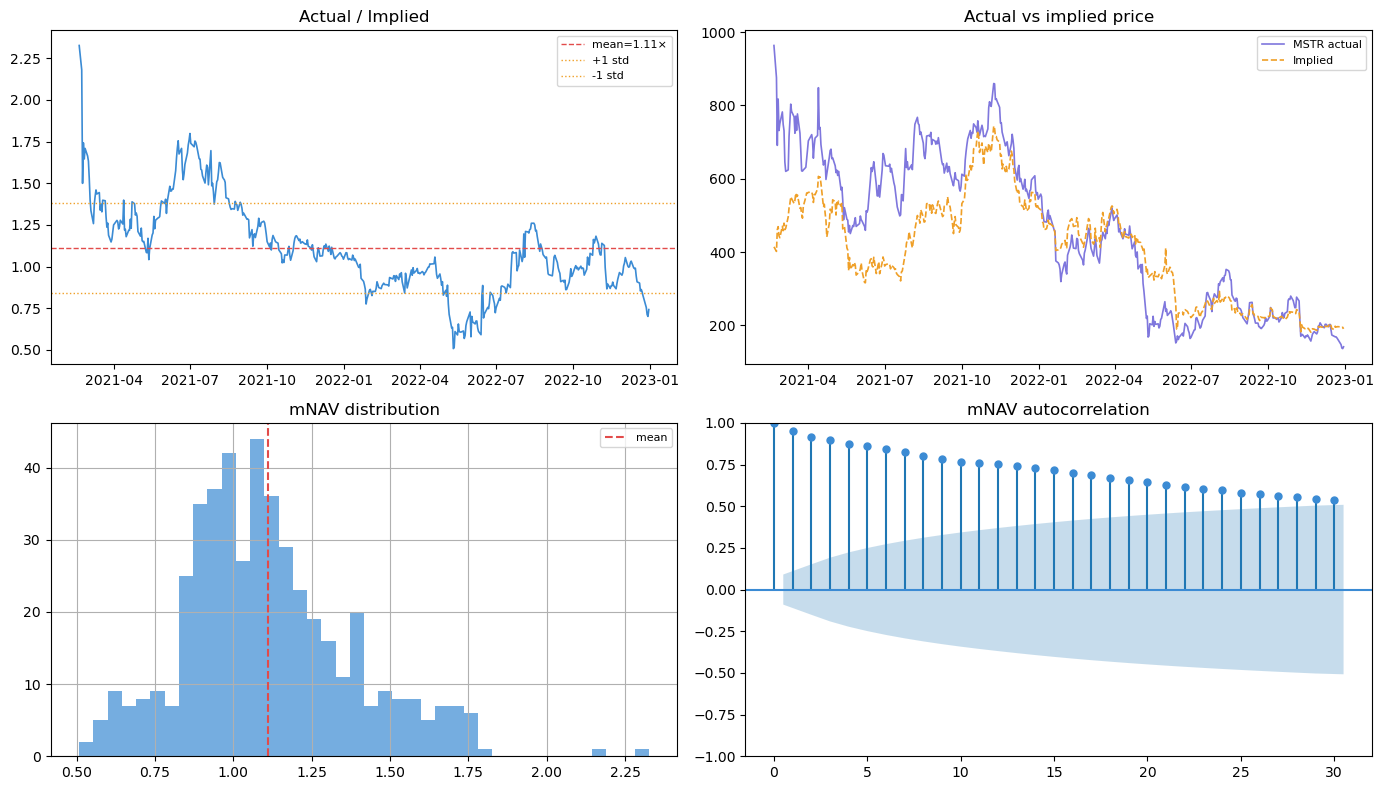

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# ── Compute mNAV ──────────────────────────────────────────────────────────────
df['mstr'] = df['mstr'] * 10
df['implied_price'] = ((df['btc_held'] / df['shares_outstanding']) * df['btc'])
df['mnav']          = df['mstr'] / df['implied_price']
# Divide btc_held by 10 before the split date


# ── 1. Summary stats ──────────────────────────────────────────────────────────
print("mNAV summary:")
print(df['mnav'].describe().round(3))
print(f"Skew:     {df['mnav'].skew():.3f}")
print(f"Kurtosis: {df['mnav'].kurt():.3f}")

# ── 2. ADF test for mean reversion ───────────────────────────────────────────
adf_result = adfuller(df['mnav'].dropna())
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Mean reverting: {'YES' if adf_result[1] < 0.05 else 'NO — signal unreliable'}")

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# mNAV over time
ax = axes[0, 0]
ax.plot(df.index, df['mnav'], color='#3B8BD4', lw=1.2)
ax.axhline(df['mnav'].mean(), color='#E24B4A', ls='--', lw=1, label=f"mean={df['mnav'].mean():.2f}×")
ax.axhline(df['mnav'].mean() + df['mnav'].std(), color='#EF9F27', ls=':', lw=1, label='+1 std')
ax.axhline(df['mnav'].mean() - df['mnav'].std(), color='#EF9F27', ls=':', lw=1, label='-1 std')
ax.set_title('Actual / Implied')
ax.legend(fontsize=8)

# Implied vs actual
ax = axes[0, 1]
ax.plot(df.index, df['mstr'],          color='#7F77DD', lw=1.2, label='MSTR actual')
ax.plot(df.index, df['implied_price'], color='#EF9F27', lw=1.2, ls='--', label='Implied')
ax.set_title('Actual vs implied price')
ax.legend(fontsize=8)

# mNAV distribution
ax = axes[1, 0]
df['mnav'].hist(bins=40, color='#3B8BD4', alpha=0.7, ax=ax)
ax.axvline(df['mnav'].mean(), color='#E24B4A', ls='--', lw=1.5, label='mean')
ax.set_title('mNAV distribution')
ax.legend(fontsize=8)

# Autocorrelation
ax = axes[1, 1]
plot_acf(df['mnav'].dropna(), lags=30, ax=ax, color='#3B8BD4')
ax.set_title('mNAV autocorrelation')

plt.tight_layout()
plt.savefig('eda.png', dpi=150)
plt.show()

  Engle-Granger Cointegration Test
  H0: No cointegration (series drift apart)
  Test statistic:  -3.0474
  p-value:         0.0994
  Critical values:
    1%:  -3.9212
    5%:  -3.3499
   10%:  -3.0540

  Cointegrated: NO ✗


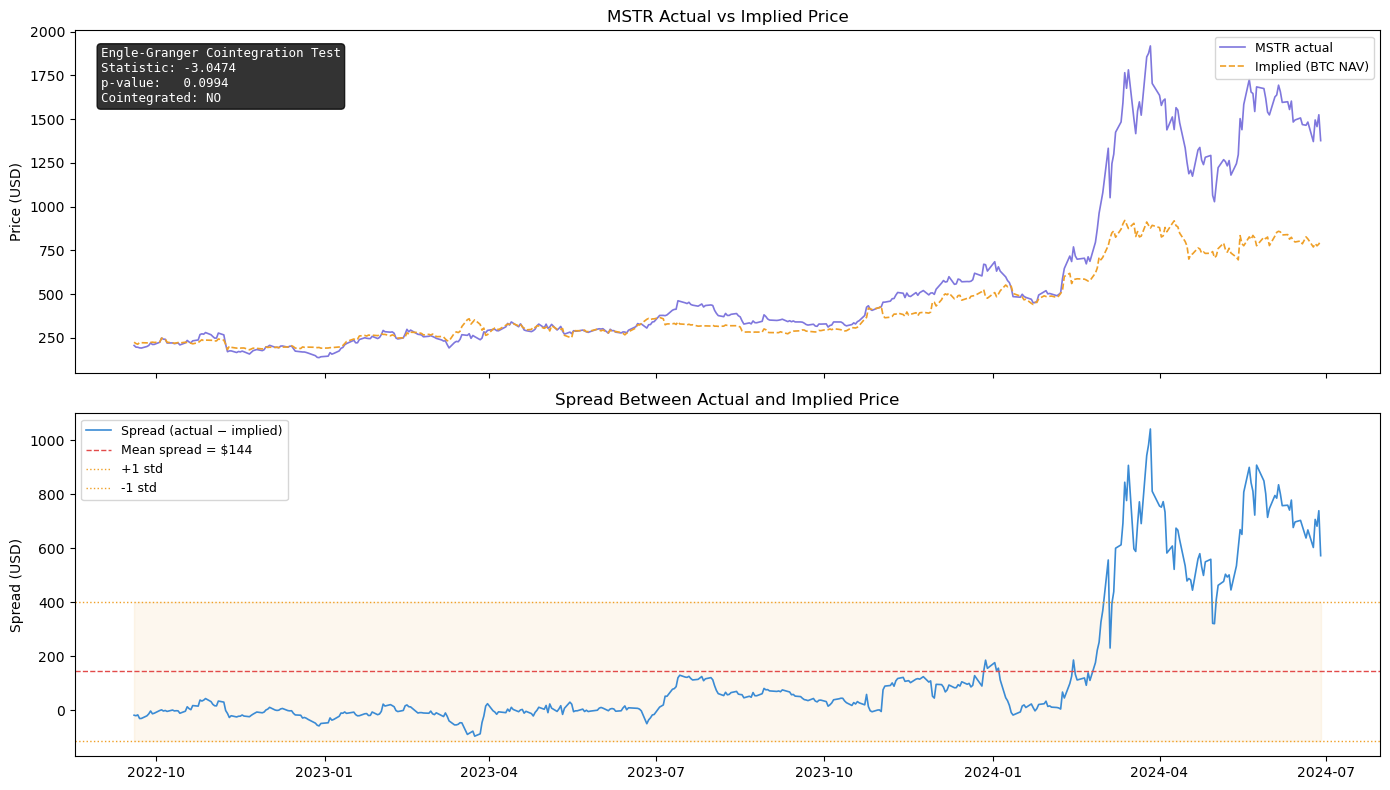

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import coint

# ── 1. Load your existing daily df ───────────────────────────────────────────
# (assumes df already has 'mstr' and 'implied_price' columns)
# If not, rebuild it:

START, END = '2022-07-01', '2024-07-01'

btc_raw  = yf.download('BTC-USD', start=START, end=END, progress=False)['Close']['BTC-USD']
mstr_raw = yf.download('MSTR',    start=START, end=END, progress=False)['Close']['MSTR']
holding_raw = pd.read_csv('btc-holdings-over-time.csv')

btc_raw.index  = pd.to_datetime(btc_raw.index).tz_localize(None)
mstr_raw.index = pd.to_datetime(mstr_raw.index).tz_localize(None)

df = pd.DataFrame({'btc': btc_raw, 'mstr': mstr_raw})

holding = holding_raw.copy()
holding['date'] = pd.to_datetime(holding['DateTime']).dt.tz_localize(None)
holding = holding.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.resample('D').last()
df = df.join(holding, how='left')
df['btc_held'] = df['btc_held'].ffill()

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)
shares = pd.Series(shares_raw, name='shares_outstanding')
shares.index = pd.to_datetime(shares.index).tz_localize(None)
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2].copy()
shares.name = 'shares_outstanding'
shares = shares.resample('D').last()
shares.name = 'shares_outstanding'
df = df.join(shares, how='left')
df['shares_outstanding'] = df['shares_outstanding'].ffill()
df = df.dropna()

df['mstr'] = df['mstr'] * 10
df['implied_price'] = (df['btc_held'] / df['shares_outstanding']) * df['btc']

# ── 2. Cointegration test ─────────────────────────────────────────────────────
# Tests whether MSTR price and implied price share a long-run equilibrium
score, pvalue, critical_values = coint(df['mstr'], df['implied_price'])

print("=" * 50)
print("  Engle-Granger Cointegration Test")
print("  H0: No cointegration (series drift apart)")
print("=" * 50)
print(f"  Test statistic:  {score:.4f}")
print(f"  p-value:         {pvalue:.4f}")
print(f"  Critical values:")
print(f"    1%:  {critical_values[0]:.4f}")
print(f"    5%:  {critical_values[1]:.4f}")
print(f"   10%:  {critical_values[2]:.4f}")
print(f"\n  Cointegrated: {'YES ✓' if pvalue < 0.05 else 'NO ✗'}")
print("=" * 50)

# ── 3. Plot spread ────────────────────────────────────────────────────────────
df['spread'] = df['mstr'] - df['implied_price']
spread_mean  = df['spread'].mean()
spread_std   = df['spread'].std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price series
ax = axes[0]
ax.plot(df.index, df['mstr'],          color='#7F77DD', lw=1.2, label='MSTR actual')
ax.plot(df.index, df['implied_price'], color='#EF9F27', lw=1.2, ls='--', label='Implied (BTC NAV)')
ax.set_title('MSTR Actual vs Implied Price')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)

# Add cointegration result as text box
textstr = (f"Engle-Granger Cointegration Test\n"
           f"Statistic: {score:.4f}\n"
           f"p-value:   {pvalue:.4f}\n"
           f"Cointegrated: {'YES' if pvalue < 0.05 else 'NO'}")
ax.text(0.02, 0.95, textstr, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.8),
        color='white', fontfamily='monospace')

# Spread
ax = axes[1]
ax.plot(df.index, df['spread'], color='#3B8BD4', lw=1.2, label='Spread (actual − implied)')
ax.axhline(spread_mean, color='#E24B4A', ls='--', lw=1,
           label=f'Mean spread = ${spread_mean:.0f}')
ax.axhline(spread_mean + spread_std, color='#EF9F27', ls=':', lw=1, label='+1 std')
ax.axhline(spread_mean - spread_std, color='#EF9F27', ls=':', lw=1, label='-1 std')
ax.fill_between(df.index, spread_mean - spread_std, spread_mean + spread_std,
                alpha=0.08, color='#EF9F27')
ax.set_title('Spread Between Actual and Implied Price')
ax.set_ylabel('Spread (USD)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('cointegration.png', dpi=150)
plt.show()

BTC rows:  8009
MSTR rows: 1589
Merged shape: (1588, 2)
Shape after holdings merge: (1560, 4)
                              btc        mstr  btc_held  shares_outstanding
time                                                                       
2025-05-07 13:00:00  97014.656250  395.165009  555450.0        2.740610e+09
2025-05-07 14:00:00  96938.171875  394.644989  555450.0        2.740610e+09
2025-05-07 15:00:00  96970.695312  391.890015  555450.0        2.740610e+09
2025-05-07 16:00:00  96880.875000  392.200012  555450.0        2.740610e+09
2025-05-07 17:00:00  96284.976562  391.070099  555450.0        2.740610e+09

mNAV mean: 121.390
mNAV std:  37.639

Z-score describe:
count    1501.000
mean       -0.552
std         1.236
min        -3.736
25%        -1.460
50%        -0.817
75%         0.406
max         3.188
Name: mnav_z, dtype: float64

Position value counts:
 0    816
 1    527
-1    217
Name: count, dtype: int64

  PORTFOLIO-LEVEL METRICS  (txn cost: 10 bps)
  Strategy return

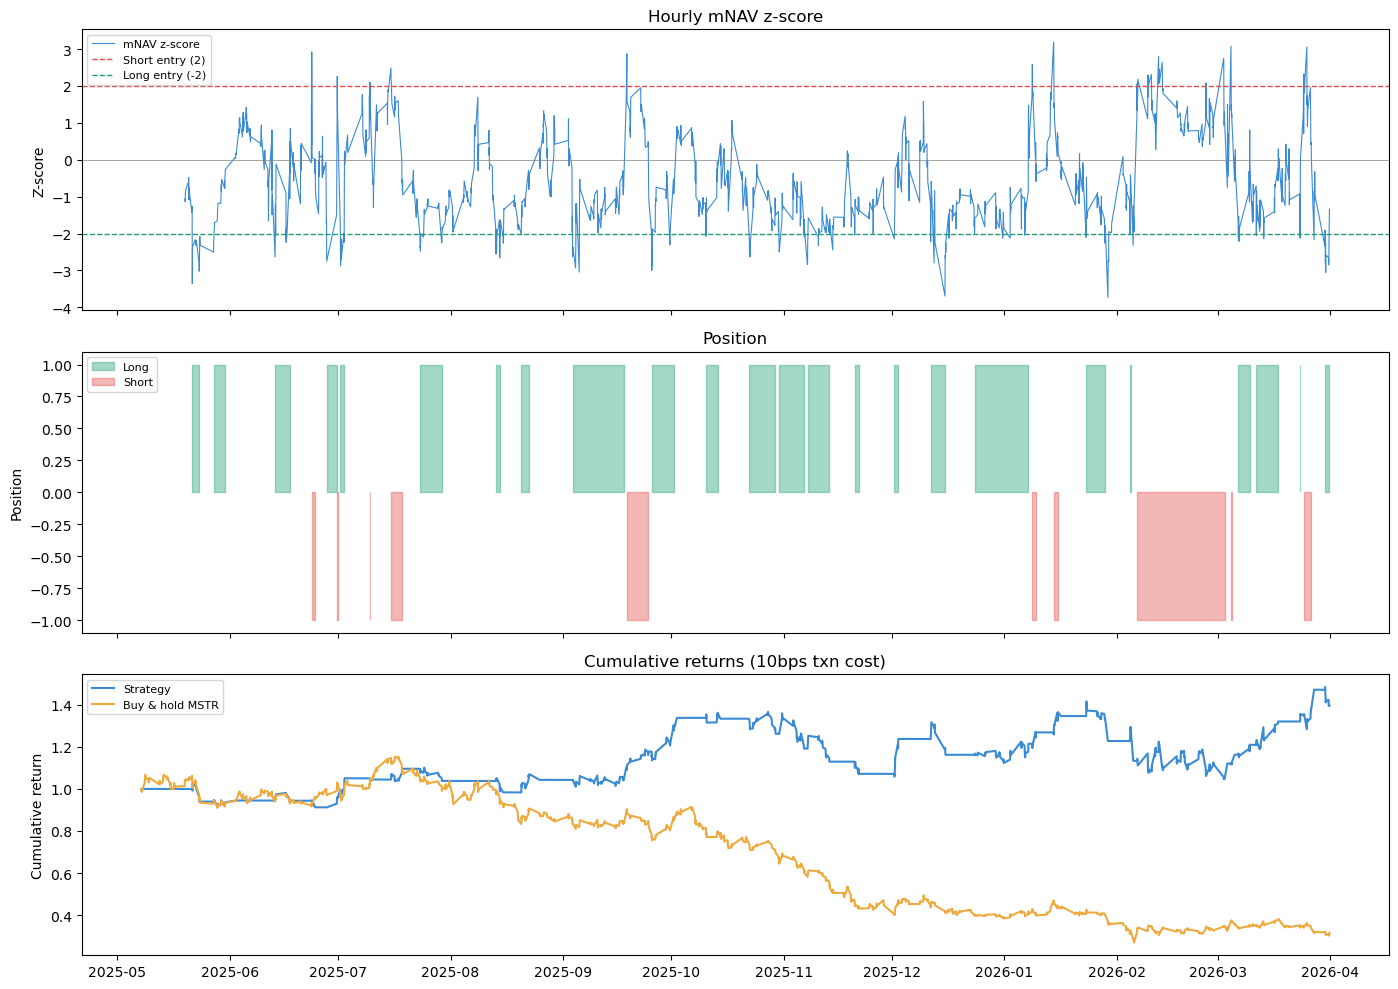

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

# ── 1. Parameters ─────────────────────────────────────────────────────────────
START, END = '2025-05-01', '2026-04-01'
COST_BPS = 10                       # round-trip transaction cost in basis points
COST = COST_BPS / 10_000            # as a decimal (0.0010)

# ── 2. Download hourly data ───────────────────────────────────────────────────
def download_hourly(ticker, start, end):
    chunks = []
    s = pd.Timestamp(start)
    e = pd.Timestamp(end)
    while s < e:
        chunk_end = min(s + pd.Timedelta(days=59), e)
        raw = yf.download(ticker, start=s, end=chunk_end,
                          interval='1h', progress=False)
        if len(raw) > 0:
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.droplevel(1)
            close = raw['Close']
            if close.index.tz is not None:
                close.index = close.index.tz_convert('UTC').tz_localize(None)
            else:
                close.index = pd.to_datetime(close.index)
            chunks.append(close)
        s = chunk_end
    if not chunks:
        raise ValueError(f"No data returned for {ticker}")
    result = pd.concat(chunks)
    result = result[~result.index.duplicated()]
    return result

print("Downloading BTC hourly...")
btc_h = download_hourly('BTC-USD', START, END)
btc_h.name = 'btc'

print("Downloading MSTR hourly...")
mstr_h = download_hourly('MSTR', START, END)
mstr_h.name = 'mstr'

print(f"BTC rows:  {len(btc_h)}")
print(f"MSTR rows: {len(mstr_h)}")

# ── 3. Load daily holdings ────────────────────────────────────────────────────
holding_raw = pd.read_csv('btc-holdings-over-time.csv')
holding_raw['date'] = pd.to_datetime(holding_raw['DateTime']).dt.tz_localize(None)
holding = holding_raw.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.resample('D').last()
holding.index = holding.index.normalize()

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)
shares = pd.Series(shares_raw, name='shares_outstanding')
shares.index = pd.to_datetime(shares.index).tz_localize(None)
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2].copy()
shares.name = 'shares_outstanding'
shares = shares.resample('D').last()
shares.name = 'shares_outstanding'
shares.index = shares.index.normalize()

# ── 4. Build hourly df ────────────────────────────────────────────────────────
btc_df = btc_h.reset_index()
btc_df.columns = ['time', 'btc']
btc_df['time'] = btc_df['time'].astype(str).str[:13]

mstr_df = mstr_h.reset_index()
mstr_df.columns = ['time', 'mstr']
mstr_df['time'] = mstr_df['time'].astype(str).str[:13]

merged = pd.merge(btc_df, mstr_df, on='time', how='inner')
merged['time'] = pd.to_datetime(merged['time'])
merged = merged.set_index('time')

print(f"Merged shape: {merged.shape}")

df = merged.copy()
df['date'] = df.index.normalize()
df['btc_held']           = df['date'].map(holding).ffill()
df['shares_outstanding']  = df['date'].map(shares).ffill() * 10
df = df.drop(columns='date')
df = df.dropna()

print(f"Shape after holdings merge: {df.shape}")
print(df.head())

# ── 5. Hourly mNAV ────────────────────────────────────────────────────────────
df['implied_price'] = (df['btc_held'] / df['shares_outstanding']) * df['btc'] / 10
df['mnav']          = df['mstr'] / df['implied_price']

print(f"\nmNAV mean: {df['mnav'].mean():.3f}")
print(f"mNAV std:  {df['mnav'].std():.3f}")

# ── 6. Rolling z-score ────────────────────────────────────────────────────────
window = 60
df['mnav_mean'] = df['mnav'].rolling(window).mean()
df['mnav_std']  = df['mnav'].rolling(window).std()
df['mnav_z']    = (df['mnav'] - df['mnav_mean']) / df['mnav_std']

print(f"\nZ-score describe:\n{df['mnav_z'].describe().round(3)}")

# ── 7. Generate positions + track individual trades ───────────────────────────
LONG_ENTRY  = -2
LONG_EXIT   =  0.0
SHORT_ENTRY =  2
SHORT_EXIT  =  0.0
STOP_LOSS   =  0.05
COOLDOWN    =  6

position      = 0
positions     = []
entry_price   = None
cooldown_left = 0

# --- Trade tracking ---
trades = []
current_trade = None

for i, (z, price) in enumerate(zip(df['mnav_z'], df['mstr'])):
    timestamp = df.index[i]

    if pd.isna(z):
        positions.append(0)
        continue

    if cooldown_left > 0:
        cooldown_left -= 1
        positions.append(0)
        continue

    # ── Stop-loss checks ──────────────────────────────────────────────────
    if position == 1 and entry_price is not None:
        if (price - entry_price) / entry_price < -STOP_LOSS:
            if current_trade is not None:
                current_trade['exit_time']  = timestamp
                current_trade['exit_price'] = price
                current_trade['exit_reason'] = 'stop_loss'
                current_trade['pnl_pct'] = (price - entry_price) / entry_price - COST
                trades.append(current_trade)
                current_trade = None
            position = 0; entry_price = None
            cooldown_left = COOLDOWN
            positions.append(0); continue

    elif position == -1 and entry_price is not None:
        if (entry_price - price) / entry_price < -STOP_LOSS:
            if current_trade is not None:
                current_trade['exit_time']  = timestamp
                current_trade['exit_price'] = price
                current_trade['exit_reason'] = 'stop_loss'
                current_trade['pnl_pct'] = (entry_price - price) / entry_price - COST
                trades.append(current_trade)
                current_trade = None
            position = 0; entry_price = None
            cooldown_left = COOLDOWN
            positions.append(0); continue

    # ── Signal logic ──────────────────────────────────────────────────────
    if position == 0:
        if z < LONG_ENTRY:
            position = 1; entry_price = price
            current_trade = {
                'direction': 'long',
                'entry_time': timestamp,
                'entry_price': price,
            }
        elif z > SHORT_ENTRY:
            position = -1; entry_price = price
            current_trade = {
                'direction': 'short',
                'entry_time': timestamp,
                'entry_price': price,
            }

    elif position == 1:
        if z > LONG_EXIT:
            if current_trade is not None:
                current_trade['exit_time']  = timestamp
                current_trade['exit_price'] = price
                current_trade['exit_reason'] = 'signal'
                current_trade['pnl_pct'] = (price - entry_price) / entry_price - COST
                trades.append(current_trade)
                current_trade = None
            position = 0; entry_price = None

    elif position == -1:
        if z < SHORT_EXIT:
            if current_trade is not None:
                current_trade['exit_time']  = timestamp
                current_trade['exit_price'] = price
                current_trade['exit_reason'] = 'signal'
                current_trade['pnl_pct'] = (entry_price - price) / entry_price - COST
                trades.append(current_trade)
                current_trade = None
            position = 0; entry_price = None

    positions.append(position)

# Handle any trade still open at end of data
if current_trade is not None:
    last_price = df['mstr'].iloc[-1]
    last_time  = df.index[-1]
    current_trade['exit_time']  = last_time
    current_trade['exit_price'] = last_price
    current_trade['exit_reason'] = 'end_of_data'
    if current_trade['direction'] == 'long':
        current_trade['pnl_pct'] = (last_price - current_trade['entry_price']) / current_trade['entry_price'] - COST
    else:
        current_trade['pnl_pct'] = (current_trade['entry_price'] - last_price) / current_trade['entry_price'] - COST
    trades.append(current_trade)

df['position'] = positions
print(f"\nPosition value counts:\n{pd.Series(positions).value_counts()}")

# ── 8. Returns (with transaction costs) ───────────────────────────────────────
df['mstr_ret']     = df['mstr'].pct_change()
df['strategy_ret'] = df['position'].shift(1) * df['mstr_ret']

# Subtract half the round-trip cost on every position change (entry or exit)
df['pos_change']    = df['position'].diff().abs()
df['strategy_ret'] -= df['pos_change'] * (COST / 2)

df['cum_strategy'] = (1 + df['strategy_ret']).cumprod()
df['cum_buyhold']  = (1 + df['mstr_ret']).cumprod()

# ── 9. Metrics (portfolio-level + trade-level) ────────────────────────────────
hours_per_year = 252 * 6.5

ret    = df['strategy_ret'].dropna()
sharpe = ret.mean() / ret.std() * np.sqrt(hours_per_year) if ret.std() > 0 else np.nan
total  = df['cum_strategy'].iloc[-1] - 1
max_dd = (df['cum_strategy'] / df['cum_strategy'].cummax() - 1).min()
n_trades = len(trades)
bh_ret   = df['mstr_ret'].dropna()
bh_total = df['cum_buyhold'].iloc[-1] - 1
bh_sharpe = bh_ret.mean() / bh_ret.std() * np.sqrt(hours_per_year)
calmar = total / abs(max_dd) if max_dd != 0 else np.nan

# ── Trade-level analytics ─────────────────────────────────────────────────
trade_df = pd.DataFrame(trades)

if len(trade_df) > 0:
    trade_df['duration'] = trade_df['exit_time'] - trade_df['entry_time']
    trade_df['duration_hours'] = trade_df['duration'].dt.total_seconds() / 3600

    avg_duration_hours = trade_df['duration_hours'].mean()
    median_duration_hours = trade_df['duration_hours'].median()
    win_rate = (trade_df['pnl_pct'] > 0).mean()
    avg_pnl_pct = trade_df['pnl_pct'].mean()
    avg_win_pnl = trade_df.loc[trade_df['pnl_pct'] > 0, 'pnl_pct'].mean() if (trade_df['pnl_pct'] > 0).any() else 0
    avg_loss_pnl = trade_df.loc[trade_df['pnl_pct'] <= 0, 'pnl_pct'].mean() if (trade_df['pnl_pct'] <= 0).any() else 0
    profit_factor = (
        trade_df.loc[trade_df['pnl_pct'] > 0, 'pnl_pct'].sum()
        / abs(trade_df.loc[trade_df['pnl_pct'] <= 0, 'pnl_pct'].sum())
    ) if (trade_df['pnl_pct'] <= 0).any() and trade_df.loc[trade_df['pnl_pct'] <= 0, 'pnl_pct'].sum() != 0 else np.inf
    stop_loss_pct = (trade_df['exit_reason'] == 'stop_loss').mean()

    long_trades  = trade_df[trade_df['direction'] == 'long']
    short_trades = trade_df[trade_df['direction'] == 'short']
else:
    avg_duration_hours = median_duration_hours = win_rate = avg_pnl_pct = 0
    avg_win_pnl = avg_loss_pnl = profit_factor = stop_loss_pct = 0
    long_trades = short_trades = pd.DataFrame()

print("\n" + "=" * 60)
print(f"  PORTFOLIO-LEVEL METRICS  (txn cost: {COST_BPS} bps)")
print("=" * 60)
print(f"  Strategy return:      {total:.1%}")
print(f"  Strategy Sharpe:      {sharpe:.2f}")
print(f"  Max drawdown:         {max_dd:.1%}")
print(f"  Calmar ratio:         {calmar:.2f}")
print(f"  ---")
print(f"  Buy & hold return:    {bh_total:.1%}")
print(f"  Buy & hold Sharpe:    {bh_sharpe:.2f}")
print("=" * 60)

print("\n" + "=" * 60)
print(f"  TRADE-LEVEL METRICS  (txn cost: {COST_BPS} bps)")
print("=" * 60)
print(f"  Number of trades:     {n_trades}")
print(f"  Win rate:             {win_rate:.1%}")
print(f"  Avg P&L per trade:    {avg_pnl_pct:.2%}")
print(f"  Avg winning trade:    {avg_win_pnl:.2%}")
print(f"  Avg losing trade:     {avg_loss_pnl:.2%}")
print(f"  Avg duration (hours): {avg_duration_hours:.1f}")
print(f"  ---")
print(f"  Long trades:          {len(long_trades)}  "
      f"(win rate: {(long_trades['pnl_pct'] > 0).mean():.1%})" if len(long_trades) > 0 else "")
print(f"  Short trades:         {len(short_trades)}  "
      f"(win rate: {(short_trades['pnl_pct'] > 0).mean():.1%})" if len(short_trades) > 0 else "")
print("=" * 60)

# ── 10. Export trade log ──────────────────────────────────────────────────────
if len(trade_df) > 0:
    trade_df.to_csv('trade_log.csv', index=False)
    print("\nTrade log saved to trade_log.csv")

# ── 11. Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
ax.plot(df.index, df['mnav_z'], color='#3B8BD4', lw=0.8, label='mNAV z-score')
ax.axhline(SHORT_ENTRY, color='#E24B4A', ls='--', lw=1, label=f'Short entry ({SHORT_ENTRY})')
ax.axhline(LONG_ENTRY,  color='#1D9E75', ls='--', lw=1, label=f'Long entry ({LONG_ENTRY})')
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.set_title('Hourly mNAV z-score')
ax.set_ylabel('Z-score')
ax.legend(fontsize=8)

ax = axes[1]
ax.fill_between(df.index, df['position'],
                where=df['position'] ==  1, color='#1D9E75', alpha=0.4, label='Long')
ax.fill_between(df.index, df['position'],
                where=df['position'] == -1, color='#E24B4A', alpha=0.4, label='Short')
ax.set_title('Position')
ax.set_ylabel('Position')
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(df.index, df['cum_strategy'], color='#3B8BD4', lw=1.5, label='Strategy')
ax.plot(df.index, df['cum_buyhold'],  color='#EFAA3F', lw=1.5, label='Buy & hold MSTR')
ax.set_title(f'Cumulative returns ({COST_BPS}bps txn cost)')
ax.set_ylabel('Cumulative return')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('hourly_strategy.png', dpi=150)
plt.show()

Base df shape: (1492, 7)
mNAV mean: 180.163  std: 68.852
  [1/112] window=6h  threshold=0.25  sharpe=-1.86  return=-97.6%  trades=288
  [2/112] window=6h  threshold=0.5  sharpe=-1.55  return=-96.5%  trades=274
  [3/112] window=6h  threshold=0.75  sharpe=-1.56  return=-96.4%  trades=248
  [4/112] window=6h  threshold=1.0  sharpe=-1.66  return=-96.6%  trades=220
  [5/112] window=6h  threshold=1.25  sharpe=-1.63  return=-96.3%  trades=190
  [6/112] window=6h  threshold=1.5  sharpe=-1.68  return=-96.2%  trades=146
  [7/112] window=6h  threshold=1.75  sharpe=-1.60  return=-95.3%  trades=93
  [8/112] window=6h  threshold=2.0  sharpe=-1.29  return=-92.0%  trades=15
  [9/112] window=6h  threshold=2.25  no trades
  [10/112] window=6h  threshold=2.5  no trades
  [11/112] window=6h  threshold=2.75  no trades
  [12/112] window=6h  threshold=3  no trades
  [13/112] window=6h  threshold=3.25  no trades
  [14/112] window=6h  threshold=3.5  no trades
  [15/112] window=6h  threshold=3.75  no trades
  [

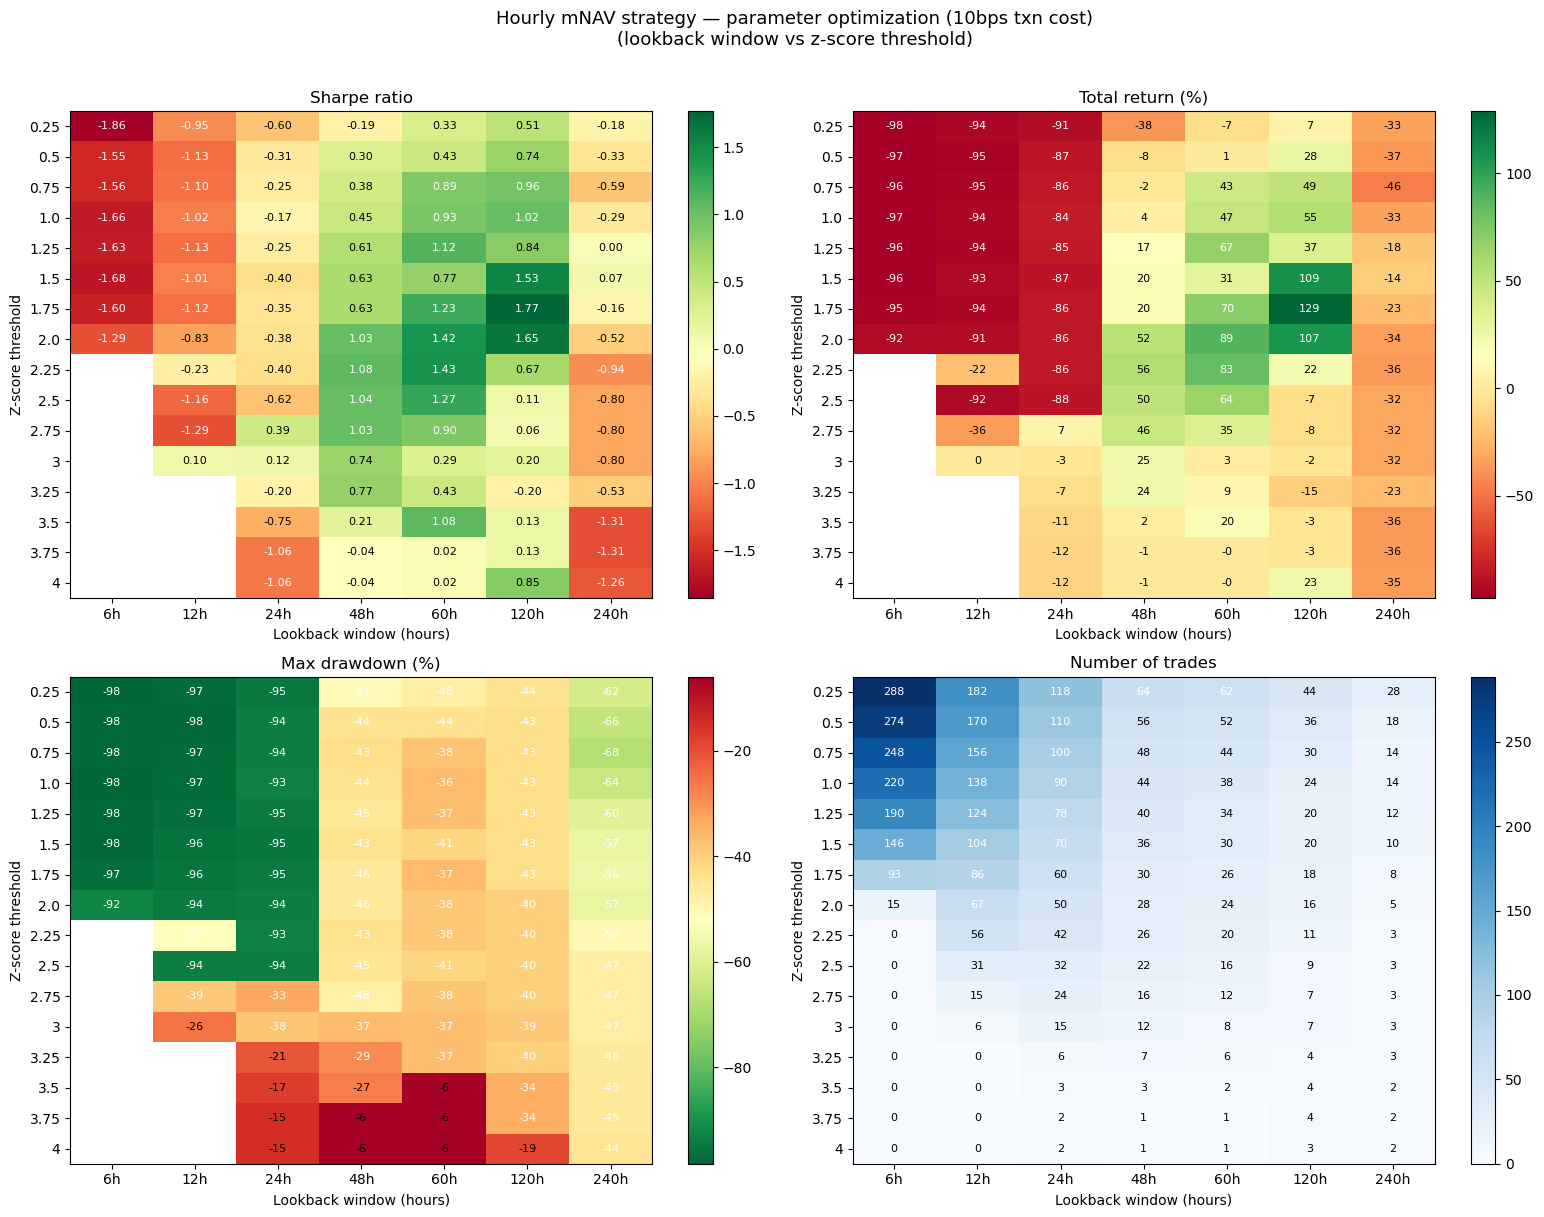


Best Sharpe:   1.77
  Window:      120h
  Threshold:   1.75×
  Return:      128.8%
  Max DD:      -42.7%
  Trades:      18


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# ── 1. Parameters ─────────────────────────────────────────────────────────────
START, END = '2024-05-01', '2025-05-01'
COST_BPS = 10                       # round-trip transaction cost in basis points
COST = COST_BPS / 10_000            # as a decimal (0.0010)

# ── 2. Download hourly data ───────────────────────────────────────────────────
def download_hourly(ticker, start, end):
    chunks = []
    s = pd.Timestamp(start)
    e = pd.Timestamp(end)
    while s < e:
        chunk_end = min(s + pd.Timedelta(days=59), e)
        raw = yf.download(ticker, start=s, end=chunk_end,
                          interval='1h', progress=False)
        if len(raw) > 0:
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.droplevel(1)
            close = raw['Close']
            if close.index.tz is not None:
                close.index = close.index.tz_convert('UTC').tz_localize(None)
            else:
                close.index = pd.to_datetime(close.index)
            chunks.append(close)
        s = chunk_end
    if not chunks:
        raise ValueError(f"No data returned for {ticker}")
    result = pd.concat(chunks)
    result = result[~result.index.duplicated()]
    return result

print("Downloading BTC hourly...")
btc_h = download_hourly('BTC-USD', START, END)
btc_h.name = 'btc'

print("Downloading MSTR hourly...")
mstr_h = download_hourly('MSTR', START, END)
mstr_h.name = 'mstr'

# ── 3. Load daily holdings ────────────────────────────────────────────────────
holding_raw = pd.read_csv('btc-holdings-over-time.csv')
holding_raw['date'] = pd.to_datetime(holding_raw['DateTime']).dt.tz_localize(None)
holding = holding_raw.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.resample('D').last()
holding.index = holding.index.normalize()

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)
shares = pd.Series(shares_raw, name='shares_outstanding')
shares.index = pd.to_datetime(shares.index).tz_localize(None)
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2].copy()
shares.name = 'shares_outstanding'
shares = shares.resample('D').last()
shares.name = 'shares_outstanding'
shares.index = shares.index.normalize()

# ── 4. Build base df ──────────────────────────────────────────────────────────
btc_df = btc_h.reset_index()
btc_df.columns = ['time', 'btc']
btc_df['time'] = btc_df['time'].astype(str).str[:13]

mstr_df = mstr_h.reset_index()
mstr_df.columns = ['time', 'mstr']
mstr_df['time'] = mstr_df['time'].astype(str).str[:13]

merged = pd.merge(btc_df, mstr_df, on='time', how='inner')
merged['time'] = pd.to_datetime(merged['time'])
merged = merged.set_index('time')

df = merged.copy()
df['date'] = df.index.normalize()
df['btc_held']           = df['date'].map(holding).ffill()
df['shares_outstanding']  = df['date'].map(shares).ffill() * 10
df = df.drop(columns='date')

df = df.dropna()
df['implied_price'] = (df['btc_held'] / df['shares_outstanding']) * df['btc'] / 10
df['mnav']          = df['mstr'] / df['implied_price']
df['mstr_ret']      = df['mstr'].pct_change()

print(f"Base df shape: {df.shape}")
print(f"mNAV mean: {df['mnav'].mean():.3f}  std: {df['mnav'].std():.3f}")

# ── 5. Strategy function (with transaction costs) ─────────────────────────────
def run_strategy(df, window, threshold, stop_loss=1, cooldown=6, cost=COST):
    d = df.copy()

    d['mnav_mean'] = d['mnav'].rolling(window).mean()
    d['mnav_std']  = d['mnav'].rolling(window).std()
    d['mnav_z']    = (d['mnav'] - d['mnav_mean']) / d['mnav_std']

    position      = 0
    positions     = []
    entry_price   = None
    cooldown_left = 0

    for z, price in zip(d['mnav_z'], d['mstr']):
        if pd.isna(z):
            positions.append(0)
            continue

        if cooldown_left > 0:
            cooldown_left -= 1
            positions.append(0)
            continue

        if position == 1 and entry_price is not None:
            if (price - entry_price) / entry_price < -stop_loss:
                position = 0; entry_price = None
                cooldown_left = cooldown
                positions.append(0); continue

        elif position == -1 and entry_price is not None:
            if (entry_price - price) / entry_price < -stop_loss:
                position = 0; entry_price = None
                cooldown_left = cooldown
                positions.append(0); continue

        if position == 0:
            if z < -threshold:
                position = 1; entry_price = price
            elif z > threshold:
                position = -1; entry_price = price
        elif position == 1:
            if z > 0:
                position = 0; entry_price = None
        elif position == -1:
            if z < 0:
                position = 0; entry_price = None

        positions.append(position)

    d['position']     = positions
    d['strategy_ret'] = d['position'].shift(1) * d['mstr_ret']

    # ── Subtract transaction cost on every position change ────────────────
    d['pos_change'] = d['position'].diff().abs()
    d['strategy_ret'] -= d['pos_change'] * (cost / 2)   # half the round-trip per leg

    ret = d['strategy_ret'].dropna()
    if len(ret) == 0 or ret.std() == 0:
        return np.nan, np.nan, np.nan, 0

    hours_per_year = 252 * 6.5
    cum      = (1 + ret).cumprod()
    sharpe   = ret.mean() / ret.std() * np.sqrt(hours_per_year)
    total    = cum.iloc[-1] - 1
    max_dd   = (cum / cum.cummax() - 1).min()
    n_trades = pd.Series(positions).diff().abs().sum() / 2

    return sharpe, total, max_dd, n_trades

# ── 6. Parameter grid ─────────────────────────────────────────────────────────
windows    = [6, 12, 24, 48, 60, 120, 240]
thresholds = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4]

sharpe_grid  = np.full((len(thresholds), len(windows)), np.nan)
return_grid  = np.full((len(thresholds), len(windows)), np.nan)
maxdd_grid   = np.full((len(thresholds), len(windows)), np.nan)
trades_grid  = np.full((len(thresholds), len(windows)), np.nan)

total_runs = len(windows) * len(thresholds)
count = 0
for j, w in enumerate(windows):
    for i, t in enumerate(thresholds):
        sharpe, ret, dd, n = run_strategy(df, w, t)
        sharpe_grid[i, j] = sharpe
        return_grid[i, j] = ret
        maxdd_grid[i, j]  = dd
        trades_grid[i, j] = n
        count += 1
        print(f"  [{count}/{total_runs}] window={w}h  threshold={t}  "
              f"sharpe={sharpe:.2f}  return={ret:.1%}  trades={n:.0f}"
              if not np.isnan(sharpe) else
              f"  [{count}/{total_runs}] window={w}h  threshold={t}  no trades")

# ── 7. Plot heatmaps ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def plot_heatmap(ax, data, title, fmt, cmap):
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(windows)))
    ax.set_xticklabels([f"{w}h" for w in windows])
    ax.set_yticks(range(len(thresholds)))
    ax.set_yticklabels(thresholds)
    ax.set_xlabel('Lookback window (hours)')
    ax.set_ylabel('Z-score threshold')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    std = np.nanstd(data)
    for i in range(len(thresholds)):
        for j in range(len(windows)):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, fmt.format(val), ha='center', va='center',
                        fontsize=8,
                        color='white' if abs(val) > std else 'black')

plot_heatmap(axes[0, 0], sharpe_grid,       'Sharpe ratio',      '{:.2f}', 'RdYlGn')
plot_heatmap(axes[0, 1], return_grid * 100, 'Total return (%)',  '{:.0f}', 'RdYlGn')
plot_heatmap(axes[1, 0], maxdd_grid  * 100, 'Max drawdown (%)',  '{:.0f}', 'RdYlGn_r')
plot_heatmap(axes[1, 1], trades_grid,       'Number of trades',  '{:.0f}', 'Blues')

plt.suptitle(f'Hourly mNAV strategy — parameter optimization ({COST_BPS}bps txn cost)\n'
             f'(lookback window vs z-score threshold)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('hourly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Best parameters ────────────────────────────────────────────────────────
best_idx = np.unravel_index(np.nanargmax(sharpe_grid), sharpe_grid.shape)
print(f"\nBest Sharpe:   {sharpe_grid[best_idx]:.2f}")
print(f"  Window:      {windows[best_idx[1]]}h")
print(f"  Threshold:   {thresholds[best_idx[0]]}×")
print(f"  Return:      {return_grid[best_idx]:.1%}")
print(f"  Max DD:      {maxdd_grid[best_idx]:.1%}")
print(f"  Trades:      {trades_grid[best_idx]:.0f}")

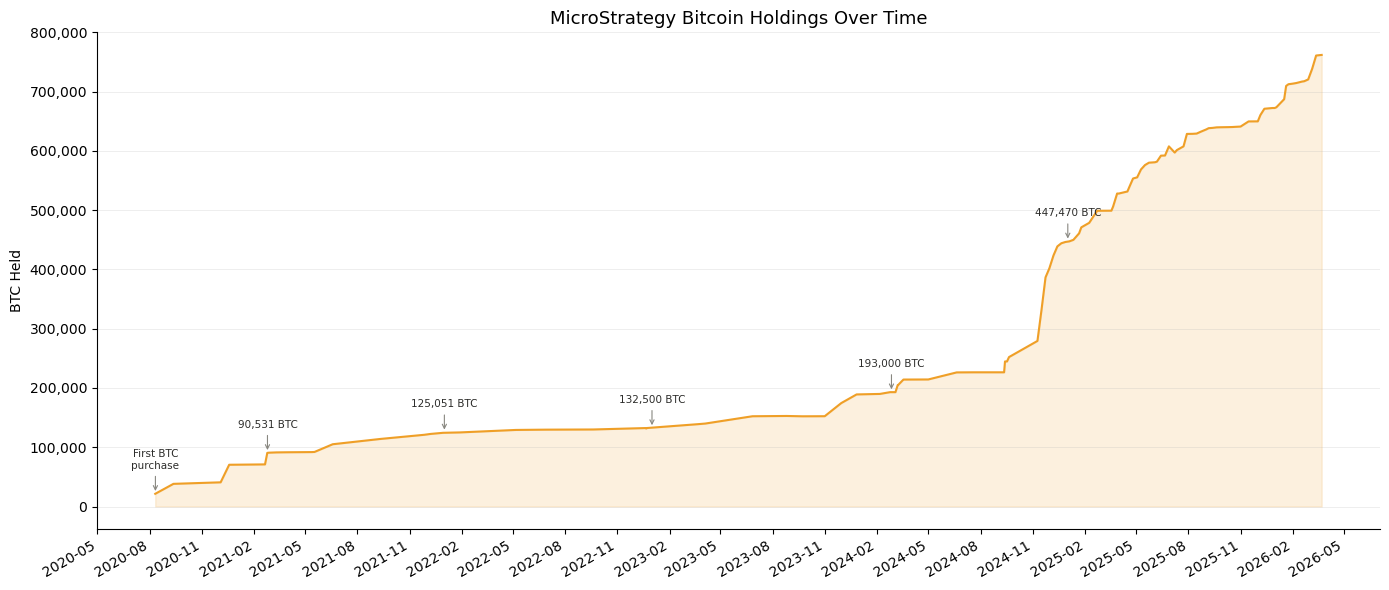

First purchase: 2020-08-10  —  21,454 BTC
Latest:         2026-03-23  —  762,099 BTC
Total growth:   35.5×


In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Load holdings ─────────────────────────────────────────────────────────────
holding_raw = pd.read_csv('btc-holdings-over-time.csv')
holding_raw['date'] = pd.to_datetime(holding_raw['DateTime']).dt.tz_localize(None)
holding = holding_raw.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.sort_index()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(holding.index, holding.values, alpha=0.15, color='#EF9F27')
ax.plot(holding.index, holding.values, color='#EF9F27', lw=1.5)

# Annotate key milestones
milestones = {
    '2020-08-11': ('First BTC\npurchase', 21454),
    '2021-02-24': ('90,531 BTC', 90531),
    '2022-01-01': ('125,051 BTC', 125051),
    '2023-01-01': ('132,500 BTC', 132500),
    '2024-02-26': ('193,000 BTC', 193000),
    '2025-01-01': ('447,470 BTC', 447470),
}

for date, (label, val) in milestones.items():
    dt = pd.Timestamp(date)
    if dt in holding.index or holding.index.searchsorted(dt) < len(holding):
        ax.annotate(label,
                    xy=(dt, val),
                    xytext=(0, 18), textcoords='offset points',
                    fontsize=7.5, color='#2C2C2A',
                    ha='center',
                    arrowprops=dict(arrowstyle='->', color='#888780', lw=0.8))

ax.set_title('MicroStrategy Bitcoin Holdings Over Time', fontsize=13)
ax.set_ylabel('BTC Held')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate()

ax.grid(axis='y', alpha=0.3, lw=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('btc_holdings.png', dpi=150)
plt.show()

print(f"First purchase: {holding.index[0].date()}  —  {holding.iloc[0]:,.0f} BTC")
print(f"Latest:         {holding.index[-1].date()}  —  {holding.iloc[-1]:,.0f} BTC")
print(f"Total growth:   {holding.iloc[-1]/holding.iloc[0]:.1f}×")

In [99]:
print(df[['btc_held', 'shares_outstanding', 'implied_price', 'mnav']].head(30))
print(f"\nFirst valid btc_held date: {df['btc_held'].first_valid_index()}")
print(f"CSV earliest date: {holding.index.min()}")

                     btc_held  shares_outstanding  implied_price      mnav
time                                                                      
2024-06-26 16:00:00  226331.0          17786200.0     779.177904  1.881098
2024-06-26 17:00:00  226331.0          17786200.0     778.557605  1.881929
2024-06-26 18:00:00  226331.0          17786200.0     775.250026  1.878104
2024-06-26 19:00:00  226331.0          17786200.0     776.850704  1.877813
2024-06-27 13:00:00  226331.0          17786200.0     786.977191  1.912355
2024-06-27 14:00:00  226331.0          17786200.0     784.893855  1.892421
2024-06-27 15:00:00  226331.0          17786200.0     783.059901  1.928167
2024-06-27 16:00:00  226331.0          17786200.0     784.799710  1.945617
2024-06-27 17:00:00  226331.0          17786200.0     786.347399  1.925606
2024-06-27 18:00:00  226331.0          17786200.0     785.729337  1.920509
2024-06-27 19:00:00  226331.0          17786200.0     781.836106  1.951675
2024-06-28 13:00:00  2263

In [143]:
import requests
import pandas as pd

API_KEY = "9ca3409a58fd7fb6daf0de6bd7a31fe58ffe70be"

url = (
    "https://api.tiingo.com/iex/MSTR/prices"
    "?startDate=2021-01-01&endDate=2021-12-31"
    f"&resampleFreq=1hour&token={API_KEY}"
)

response = requests.get(url)
data = response.json()

print(data)

[{'date': '2021-01-04T15:00:00.000Z', 'close': 432.47, 'high': 440.0, 'low': 429.48, 'open': 437.01}, {'date': '2021-01-04T16:00:00.000Z', 'close': 434.39, 'high': 435.66, 'low': 423.14, 'open': 431.3}, {'date': '2021-01-04T17:00:00.000Z', 'close': 422.72, 'high': 434.39, 'low': 417.415, 'open': 434.39}, {'date': '2021-01-04T18:00:00.000Z', 'close': 425.17, 'high': 427.48, 'low': 422.28, 'open': 422.72}, {'date': '2021-01-04T19:00:00.000Z', 'close': 417.6, 'high': 425.17, 'low': 412.0, 'open': 425.17}, {'date': '2021-01-04T20:00:00.000Z', 'close': 425.27, 'high': 425.85, 'low': 416.45, 'open': 417.85}, {'date': '2021-01-05T15:00:00.000Z', 'close': 411.41, 'high': 422.99, 'low': 407.04, 'open': 421.4}, {'date': '2021-01-05T16:00:00.000Z', 'close': 411.38, 'high': 417.42, 'low': 407.66, 'open': 411.41}, {'date': '2021-01-05T17:00:00.000Z', 'close': 420.97, 'high': 420.97, 'low': 410.2, 'open': 410.92}, {'date': '2021-01-05T18:00:00.000Z', 'close': 421.74, 'high': 421.79, 'low': 417.42, '

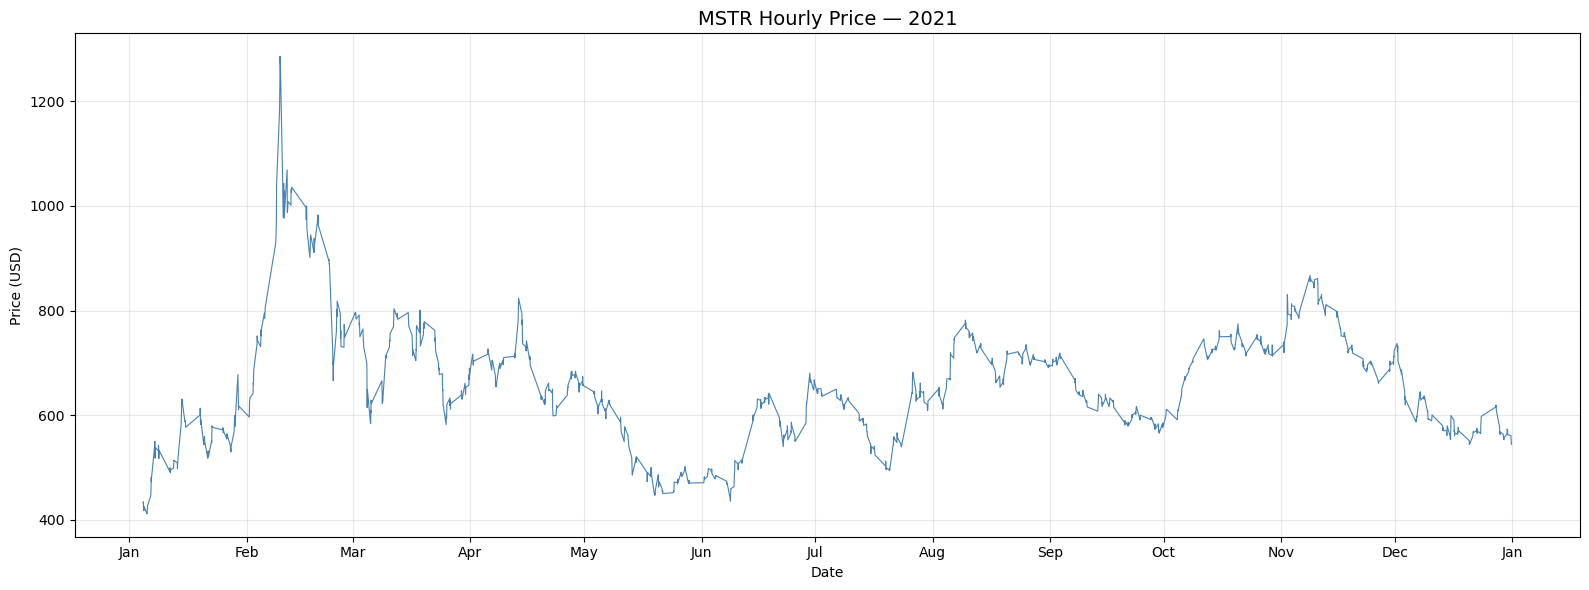

In [144]:
df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])

# Filter out flat holiday/weekend carry-forward rows
df = df[df['close'] != df['close'].shift(1)]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['close'], linewidth=0.8, color='steelblue')

ax.set_title('MSTR Hourly Price — 2021', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mstr_2021_hourly.png', dpi=150)
plt.show()

Shape: (830, 9)

mNAV summary:
count    830.000
mean       0.988
std        0.116
min        0.695
25%        0.907
50%        0.982
75%        1.056
max        1.281
Name: mnav, dtype: float64
Skew:     0.267
Kurtosis: 0.002

ADF statistic: -2.1851
p-value:       0.2117
Mean reverting: NO — signal unreliable


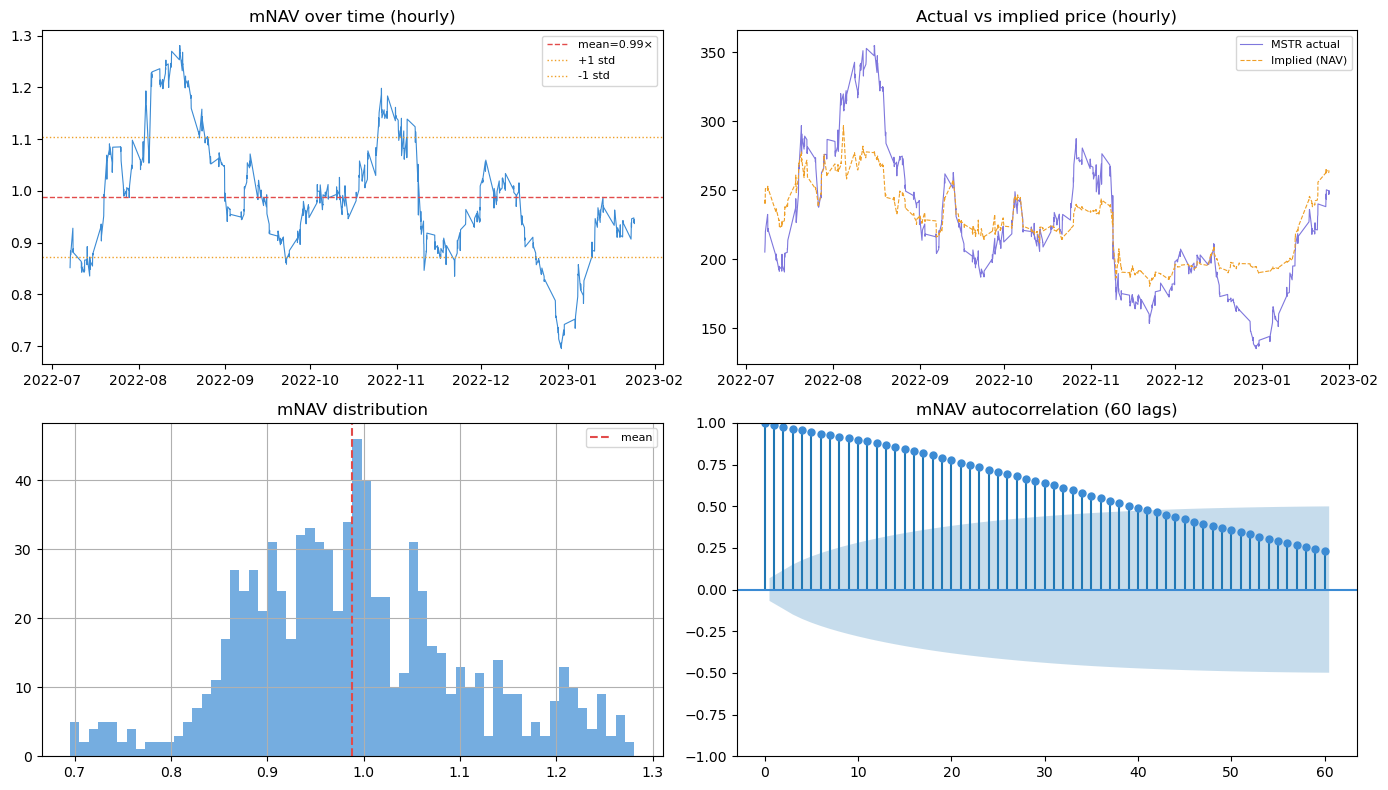

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import requests
import yfinance as yf

API_KEY = "9ca3409a58fd7fb6daf0de6bd7a31fe58ffe70be"

START = '2022-07-01'
END   = '2024-06-01'

# ── Pull hourly MSTR from Tiingo ──────────────────────────────────────────────
url_mstr = (
    f"https://api.tiingo.com/iex/MSTR/prices"
    f"?startDate={START}&endDate={END}"
    f"&resampleFreq=1hour&token={API_KEY}"
)
mstr_data = requests.get(url_mstr).json()

df = pd.DataFrame(mstr_data)
df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
df = df.set_index('date').sort_index()
df = df[df['close'] != df['close'].shift(1)]
df = df[['open', 'high', 'low', 'close']].rename(columns={'close': 'mstr'})

# ── Pull hourly BTC from Tiingo crypto endpoint ───────────────────────────────
url_btc = (
    f"https://api.tiingo.com/tiingo/crypto/prices"
    f"?tickers=btcusd"
    f"&startDate={START}&endDate={END}"
    f"&resampleFreq=1hour&token={API_KEY}"
)
btc_raw = requests.get(url_btc).json()

btc_records = btc_raw[0]['priceData']
btc_df = pd.DataFrame(btc_records)
btc_df['date'] = pd.to_datetime(btc_df['date']).dt.tz_convert(None)
btc_df = btc_df.set_index('date').sort_index()
btc_df = btc_df[['close']].rename(columns={'close': 'btc'})

# ── Join MSTR and BTC ─────────────────────────────────────────────────────────
df = df.join(btc_df, how='inner')

# ── BTC holdings from CSV ─────────────────────────────────────────────────────
holding_raw = pd.read_csv('btc-holdings-over-time.csv')
holding = holding_raw.copy()
holding['date'] = pd.to_datetime(holding['DateTime']).dt.tz_localize(None)
holding = holding.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.resample('h').last().ffill()
df = df.join(holding, how='left')
df['btc_held'] = df['btc_held'].ffill()

# ── Shares outstanding from yfinance ─────────────────────────────────────────
mstr_ticker = yf.Ticker('MSTR')
shares_raw = mstr_ticker.get_shares_full(start=START, end=END)
shares = shares_raw.copy()
shares.index = pd.to_datetime(shares.index).tz_convert(None)
shares.name = 'shares_outstanding'

median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2]
shares = shares.resample('h').last().ffill()

df = df.join(shares, how='left')
df['shares_outstanding'] = df['shares_outstanding'].ffill()

# ── Compute mNAV ──────────────────────────────────────────────────────────────
df['implied_price'] = (df['btc_held'] / df['shares_outstanding']) * df['btc']
df['mnav'] = df['mstr'] / df['implied_price']

df = df.dropna()

print("Shape:", df.shape)
print("\nmNAV summary:")
print(df['mnav'].describe().round(3))
print(f"Skew:     {df['mnav'].skew():.3f}")
print(f"Kurtosis: {df['mnav'].kurt():.3f}")

# ── ADF test ──────────────────────────────────────────────────────────────────
adf_result = adfuller(df['mnav'].dropna())
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Mean reverting: {'YES' if adf_result[1] < 0.05 else 'NO — signal unreliable'}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ax = axes[0, 0]
ax.plot(df.index, df['mnav'], color='#3B8BD4', lw=0.8)
ax.axhline(df['mnav'].mean(), color='#E24B4A', ls='--', lw=1, label=f"mean={df['mnav'].mean():.2f}×")
ax.axhline(df['mnav'].mean() + df['mnav'].std(), color='#EF9F27', ls=':', lw=1, label='+1 std')
ax.axhline(df['mnav'].mean() - df['mnav'].std(), color='#EF9F27', ls=':', lw=1, label='-1 std')
ax.set_title('mNAV over time (hourly)')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(df.index, df['mstr'],          color='#7F77DD', lw=0.8, label='MSTR actual')
ax.plot(df.index, df['implied_price'], color='#EF9F27', lw=0.8, ls='--', label='Implied (NAV)')
ax.set_title('Actual vs implied price (hourly)')
ax.legend(fontsize=8)

ax = axes[1, 0]
df['mnav'].hist(bins=60, color='#3B8BD4', alpha=0.7, ax=ax)
ax.axvline(df['mnav'].mean(), color='#E24B4A', ls='--', lw=1.5, label='mean')
ax.set_title('mNAV distribution')
ax.legend(fontsize=8)

ax = axes[1, 1]
plot_acf(df['mnav'].dropna(), lags=60, ax=ax, color='#3B8BD4')
ax.set_title('mNAV autocorrelation (60 lags)')

plt.tight_layout()
plt.savefig('eda_hourly.png', dpi=150)
plt.show()

In [160]:
import pandas as pd
import requests
from dateutil.relativedelta import relativedelta

API_KEY = "f46057ee02788a8701285c86b17709be63dec0bd"

FULL_START = pd.Timestamp('2025-01-01')
FULL_END   = pd.Timestamp('2026-01-01')
INTERVAL   = relativedelta(months=3)

# ── Helper: generate 3-month windows ─────────────────────────────────────────
def generate_windows(start, end, interval):
    windows = []
    s = start
    while s < end:
        e = min(s + interval, end)
        windows.append((s.strftime('%Y-%m-%d'), e.strftime('%Y-%m-%d')))
        s = e
    return windows

windows = generate_windows(FULL_START, FULL_END, INTERVAL)
print(f"Pulling {len(windows)} windows:")
for w in windows:
    print(f"  {w[0]} → {w[1]}")

# ── Helper: fetch MSTR hourly for one window ──────────────────────────────────
def fetch_mstr(start, end):
    url = (
        f"https://api.tiingo.com/iex/MSTR/prices"
        f"?startDate={start}&endDate={end}"
        f"&resampleFreq=1hour&token={API_KEY}"
    )
    data = requests.get(url).json()

    if not data or not isinstance(data, list):
        print(f"    WARNING: unexpected MSTR response for {start}→{end}: {data}")
        return pd.DataFrame()

    df = pd.DataFrame(data)
    if df.empty or 'close' not in df.columns:
        print(f"    WARNING: no close column in MSTR data for {start}→{end}")
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
    df = df.set_index('date').sort_index()
    df = df[['open', 'high', 'low', 'close']].rename(columns={'close': 'mstr'})
    df = df[df['mstr'] != df['mstr'].shift(1)]
    return df

# ── Helper: fetch BTC hourly for one window ───────────────────────────────────
def fetch_btc(start, end):
    url = (
        f"https://api.tiingo.com/tiingo/crypto/prices"
        f"?tickers=btcusd"
        f"&startDate={start}&endDate={end}"
        f"&resampleFreq=1hour&token={API_KEY}"
    )
    raw = requests.get(url).json()

    if not raw or not isinstance(raw, list) or not raw[0].get('priceData'):
        print(f"    WARNING: unexpected BTC response for {start}→{end}: {raw}")
        return pd.DataFrame()

    btc_df = pd.DataFrame(raw[0]['priceData'])
    if btc_df.empty or 'close' not in btc_df.columns:
        print(f"    WARNING: no close column in BTC data for {start}→{end}")
        return pd.DataFrame()

    btc_df['date'] = pd.to_datetime(btc_df['date']).dt.tz_convert(None)
    btc_df = btc_df.set_index('date').sort_index()
    btc_df = btc_df[['close']].rename(columns={'close': 'btc'})
    return btc_df

# ── Pull and stitch all windows ───────────────────────────────────────────────
mstr_chunks = []
btc_chunks  = []

for i, (s, e) in enumerate(windows):
    print(f"\n[{i+1}/{len(windows)}] Fetching {s} → {e} ...", end=' ')
    m = fetch_mstr(s, e)
    b = fetch_btc(s, e)
    print(f"MSTR rows: {len(m)}, BTC rows: {len(b)}")
    mstr_chunks.append(m)
    btc_chunks.append(b)

# Filter out empty chunks
mstr_chunks = [c for c in mstr_chunks if not c.empty]
btc_chunks  = [c for c in btc_chunks  if not c.empty]

if not mstr_chunks or not btc_chunks:
    raise RuntimeError("All chunks empty — check your API key and date ranges")

mstr_all = pd.concat(mstr_chunks).sort_index()
btc_all  = pd.concat(btc_chunks).sort_index()

# Deduplicate at chunk boundaries
mstr_all = mstr_all[~mstr_all.index.duplicated(keep='last')]
btc_all  = btc_all[~btc_all.index.duplicated(keep='last')]

print(f"\nStitched MSTR: {mstr_all.shape}  |  {mstr_all.index.min()} → {mstr_all.index.max()}")
print(f"Stitched BTC:  {btc_all.shape}   |  {btc_all.index.min()} → {btc_all.index.max()}")

# ── Save to CSV ───────────────────────────────────────────────────────────────
mstr_all.to_csv('mstr_hourlyfinal.csv')
btc_all.to_csv('btc_hourlyfinal.csv')

print("\nSaved:")
print("  mstr_hourlyfinal.csv  — columns: open, high, low, mstr")
print("  btc_hourlyfinal.csv   — columns: btc")
print("\nDone.")

Pulling 4 windows:
  2025-01-01 → 2025-04-01
  2025-04-01 → 2025-07-01
  2025-07-01 → 2025-10-01
  2025-10-01 → 2026-01-01

[1/4] Fetching 2025-01-01 → 2025-04-01 ... MSTR rows: 364, BTC rows: 2161

[2/4] Fetching 2025-04-01 → 2025-07-01 ... MSTR rows: 378, BTC rows: 2179

[3/4] Fetching 2025-07-01 → 2025-10-01 ... MSTR rows: 386, BTC rows: 2209

[4/4] Fetching 2025-10-01 → 2026-01-01 ... MSTR rows: 376, BTC rows: 2209

Stitched MSTR: (1486, 4)  |  2025-01-02 15:00:00 → 2025-12-31 20:00:00
Stitched BTC:  (8755, 1)   |  2025-01-01 00:00:00 → 2026-01-01 00:00:00

Saved:
  mstr_hourlyfinal.csv  — columns: open, high, low, mstr
  btc_hourlyfinal.csv   — columns: btc

Done.


  HEDGE WEIGHT (nav / mstr  =  1 / mNAV)
  Mean   : 0.991
  Std    : 0.114
  Min    : 0.781
  Max    : 1.351

  HEDGED RETURN DISTRIBUTION
  Mean   : 0.000913
  Std    : 0.017291
  Skew   : 0.589
  Kurt   : 5.829

  ADF: hedged_ret (should be stationary)
  Statistic : -7.7541
  p-value   : 0.0000
  Stationary: YES ✓

  ADF: cum_hedged (key stationarity test)
  Statistic : -2.1463
  p-value   : 0.2263
  Stationary: NO ✗

  ADF: mNAV (context)
  Statistic : -2.4186
  p-value   : 0.1366
  Stationary: NO ✗


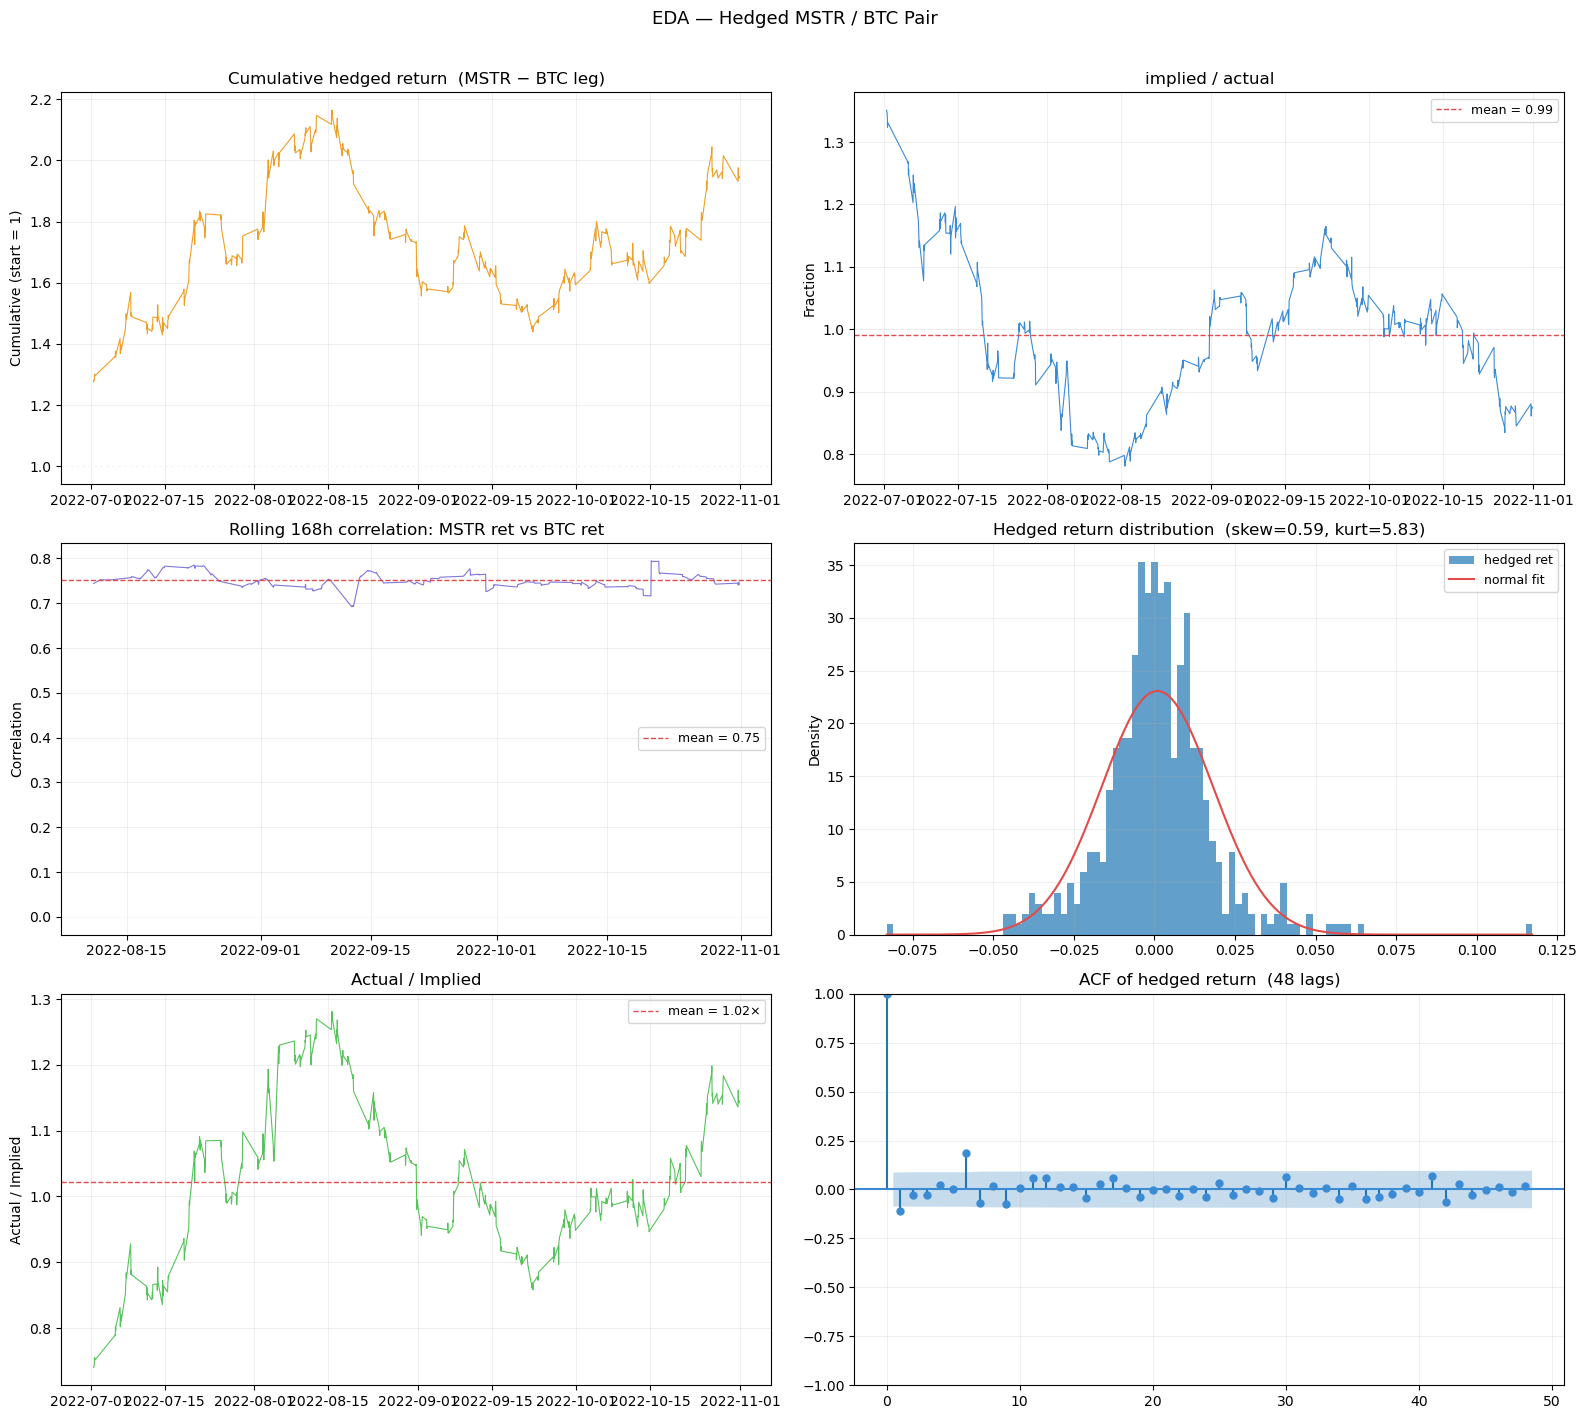

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import yfinance as yf
import scipy.stats as stats

# ── Load and stitch ───────────────────────────────────────────────────────────
mstr = pd.read_csv('mstr_hourly1.csv', parse_dates=['date'])
btc  = pd.read_csv('btc_hourly1.csv',  parse_dates=['date'])

df = pd.merge(mstr, btc, on='date', how='inner')
df = df.set_index('date').sort_index()


# ── BTC holdings ──────────────────────────────────────────────────────────────
holding_raw = pd.read_csv('btc-holdings-over-time.csv')
holding = holding_raw.copy()
holding['date'] = pd.to_datetime(holding['DateTime']).dt.tz_localize(None)
holding = holding.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.resample('h').last().ffill()
df = df.join(holding, how='left')
df['btc_held'] = df['btc_held'].ffill()

# ── Shares outstanding ────────────────────────────────────────────────────────
START = df.index.min().strftime('%Y-%m-%d')
END   = df.index.max().strftime('%Y-%m-%d')

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)
shares = shares_raw.copy()
shares.index = pd.to_datetime(shares.index).tz_localize(None)
shares.name = 'shares_outstanding'
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2]
shares = shares.resample('h').last().ffill()
df = df.join(shares, how='left')
df['shares_outstanding'] = df['shares_outstanding'].ffill()
df = df.dropna(subset=['mstr', 'btc', 'btc_held', 'shares_outstanding'])


# ── Core series ───────────────────────────────────────────────────────────────
df['btc_per_share'] = df['btc_held'] / df['shares_outstanding']
df['nav']           = df['btc_per_share'] * df['btc']
df['mnav']          = df['mstr'] / df['nav']
df['hedge_weight']  = df['nav'] / df['mstr']        # = 1 / mnav

df['mstr_ret']      = df['mstr'].pct_change()
df['btc_ret']       = df['btc'].pct_change()
df['hedged_ret']    = df['mstr_ret'] - df['hedge_weight'].shift(1) * df['btc_ret']
df['cum_hedged']    = (1 + df['hedged_ret'].fillna(0)).cumprod()

df = df.dropna(subset=['mstr_ret', 'btc_ret', 'hedged_ret'])
df = df[(df.index >= '2022-07-01') & (df.index <= '2022-11-01')]

# ── Rolling stats ─────────────────────────────────────────────────────────────
WINDOW = 168
df['rolling_corr']       = df['mstr_ret'].rolling(WINDOW).corr(df['btc_ret'])
df['hedged_ret_cum_roll'] = df['hedged_ret'].rolling(WINDOW).sum()

# ═════════════════════════════════════════════════════════════════════════════
# PRINT STATS
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 52)
print("  HEDGE WEIGHT (nav / mstr  =  1 / mNAV)")
print("=" * 52)
print(f"  Mean   : {df['hedge_weight'].mean():.3f}")
print(f"  Std    : {df['hedge_weight'].std():.3f}")
print(f"  Min    : {df['hedge_weight'].min():.3f}")
print(f"  Max    : {df['hedge_weight'].max():.3f}")

print()
print("=" * 52)
print("  HEDGED RETURN DISTRIBUTION")
print("=" * 52)
print(f"  Mean   : {df['hedged_ret'].mean():.6f}")
print(f"  Std    : {df['hedged_ret'].std():.6f}")
print(f"  Skew   : {df['hedged_ret'].skew():.3f}")
print(f"  Kurt   : {df['hedged_ret'].kurt():.3f}")

print()
print("=" * 52)
print("  ADF: hedged_ret (should be stationary)")
print("=" * 52)
adf_ret = adfuller(df['hedged_ret'].dropna())
print(f"  Statistic : {adf_ret[0]:.4f}")
print(f"  p-value   : {adf_ret[1]:.4f}")
print(f"  Stationary: {'YES ✓' if adf_ret[1] < 0.05 else 'NO ✗'}")

print()
print("=" * 52)
print("  ADF: cum_hedged (key stationarity test)")
print("=" * 52)
adf_cum = adfuller(df['cum_hedged'].dropna())
print(f"  Statistic : {adf_cum[0]:.4f}")
print(f"  p-value   : {adf_cum[1]:.4f}")
print(f"  Stationary: {'YES ✓' if adf_cum[1] < 0.05 else 'NO ✗'}")

print()
print("=" * 52)
print("  ADF: mNAV (context)")
print("=" * 52)
adf_mnav = adfuller(df['mnav'].dropna())
print(f"  Statistic : {adf_mnav[0]:.4f}")
print(f"  p-value   : {adf_mnav[1]:.4f}")
print(f"  Stationary: {'YES ✓' if adf_mnav[1] < 0.05 else 'NO ✗'}")

# ═════════════════════════════════════════════════════════════════════════════
# PLOTS  (2x3 grid)
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('EDA — Hedged MSTR / BTC Pair', fontsize=13, y=1.01)

# 1. Cumulative hedged return
ax = axes[0, 0]
ax.plot(df.index, df['cum_hedged'], color='#EF9F27', lw=0.8)
ax.axhline(1.0, color='white', ls='--', lw=0.8)
ax.set_title('Cumulative hedged return  (MSTR − BTC leg)')
ax.set_ylabel('Cumulative (start = 1)')
ax.grid(True, alpha=0.2)

# 2. Hedge weight over time
ax = axes[0, 1]
ax.plot(df.index, df['hedge_weight'], color='#3B8BD4', lw=0.8)
ax.axhline(df['hedge_weight'].mean(), color='#E24B4A', ls='--', lw=1,
           label=f"mean = {df['hedge_weight'].mean():.2f}")
ax.set_title('implied / actual')
ax.set_ylabel('Fraction')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# 3. Rolling correlation MSTR vs BTC returns
ax = axes[1, 0]
ax.plot(df.index, df['rolling_corr'], color='#7F77DD', lw=0.8)
ax.axhline(df['rolling_corr'].mean(), color='#E24B4A', ls='--', lw=1,
           label=f"mean = {df['rolling_corr'].mean():.2f}")
ax.axhline(0, color='white', ls='-', lw=0.5)
ax.set_title(f'Rolling {WINDOW}h correlation: MSTR ret vs BTC ret')
ax.set_ylabel('Correlation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# 4. Hedged return distribution + normal overlay
ax = axes[1, 1]
ret_clean = df['hedged_ret'].dropna()
ax.hist(ret_clean, bins=100, alpha=0.7, density=True, label='hedged ret')
x = np.linspace(ret_clean.min(), ret_clean.max(), 300)
ax.plot(x, stats.norm.pdf(x, ret_clean.mean(), ret_clean.std()),
        color='#E24B4A', lw=1.5, label='normal fit')
ax.set_title(f'Hedged return distribution  (skew={ret_clean.skew():.2f}, kurt={ret_clean.kurt():.2f})')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# 5. mNAV over time (context only)
ax = axes[2, 0]
ax.plot(df.index, df['mnav'], color='#56C45A', lw=0.8)
ax.axhline(df['mnav'].mean(), color='#E24B4A', ls='--', lw=1,
           label=f"mean = {df['mnav'].mean():.2f}×")
ax.set_title('Actual / Implied')
ax.set_ylabel('Actual / Implied')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# 6. ACF of hedged return
ax = axes[2, 1]
plot_acf(ret_clean, lags=48, ax=ax, color='#3B8BD4', alpha=0.05)
ax.set_title('ACF of hedged return  (48 lags)')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('eda_hedged.png', dpi=150)
plt.show()

Period:         2022-07-01 → 2023-12-29
Daily obs:      377
mNAV mean:      1.056  std: 0.147

Raw mNAV
  Actual crossings  : 33
  Sim mean          : 16.4
  95th pct of sims  : 36
  % RWs below actual: 91.9%

Rolling z-score
  Actual crossings  : 42
  Sim mean          : 15.9
  95th pct of sims  : 34
  % RWs below actual: 98.9%


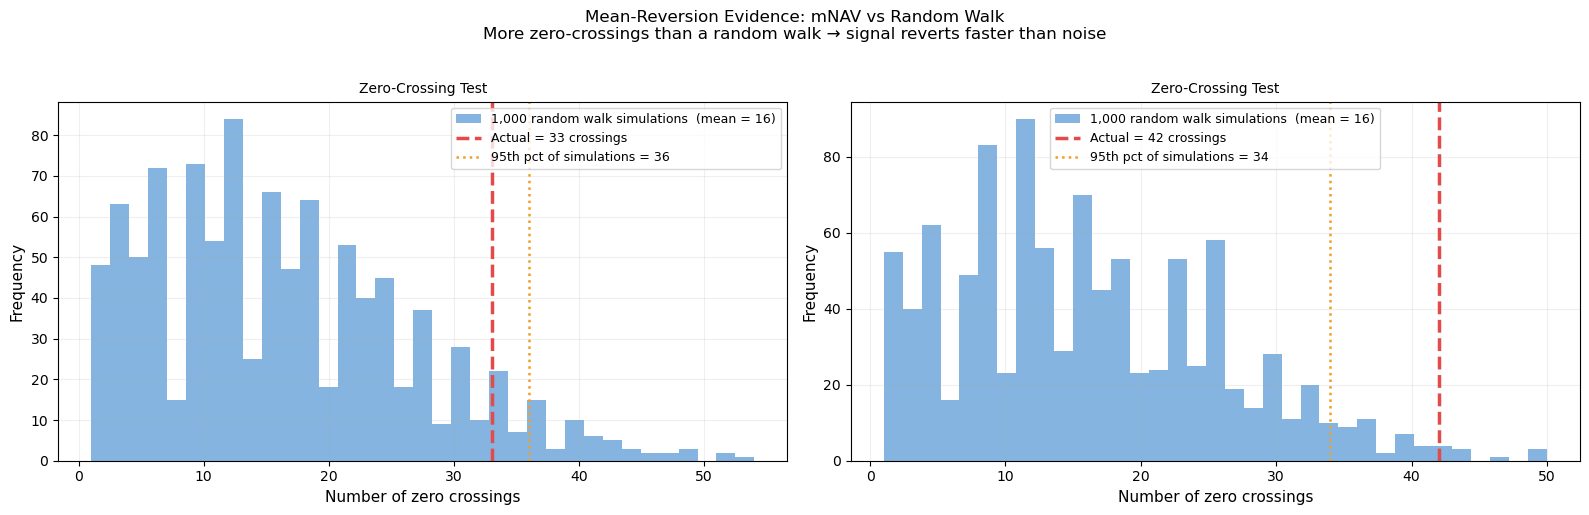

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load and merge ─────────────────────────────────────────────────────────
mstr = pd.read_csv('mstr_hourly1.csv', parse_dates=['date'])
btc  = pd.read_csv('btc_hourly1.csv',  parse_dates=['date'])

df = pd.merge(mstr, btc, on='date', how='inner')
df = df.set_index('date').sort_index()

# ── 2. BTC holdings ───────────────────────────────────────────────────────────
holding_raw = pd.read_csv('btc-holdings-over-time.csv')
holding_raw.columns = (holding_raw.columns
                       .str.replace('\ufeff', '')
                       .str.strip().str.strip('"'))
holding = holding_raw.copy()
holding['date'] = pd.to_datetime(
    holding_raw['DateTime'].str.strip('"')).dt.tz_localize(None)
holding = holding.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.resample('h').last().ffill()
df = df.join(holding, how='left')
df['btc_held'] = df['btc_held'].ffill()

# ── 3. Shares outstanding ─────────────────────────────────────────────────────
# Replace with yf.Ticker('MSTR').get_shares_full() if network is available.
# Approximate quarterly pre-split share counts from public filings.
import yfinance as yf

START = df.index.min().strftime('%Y-%m-%d')
END   = df.index.max().strftime('%Y-%m-%d')

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)
shares = shares_raw.copy()
shares.index = pd.to_datetime(shares.index).tz_localize(None)
shares.name = 'shares_outstanding'
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2]
shares = shares.resample('h').last().ffill()
df = df.join(shares, how='left')
df['shares_outstanding'] = df['shares_outstanding'].ffill()
df = df.dropna(subset=['mstr', 'btc', 'btc_held', 'shares_outstanding'])

# ── 4. mNAV ───────────────────────────────────────────────────────────────────
df['btc_per_share'] = df['btc_held'] / df['shares_outstanding']
df['nav']           = df['btc_per_share'] * df['btc']
df['mnav']          = df['mstr'] / df['nav']

# In-sample only
df = df[df.index >= '2022-07-01']

# Downsample to daily closes for zero-crossing test
# (hourly data has mechanical autocorrelation that inflates crossing counts)
daily_mnav  = df['mnav'].resample('D').last().dropna()

# Also compute rolling z-score (168h window) and downsample
WINDOW = 168
df['mnav_mean'] = df['mnav'].rolling(WINDOW).mean()
df['mnav_std']  = df['mnav'].rolling(WINDOW).std()
df['mnav_z']    = (df['mnav'] - df['mnav_mean']) / df['mnav_std']
daily_zscore = df['mnav_z'].resample('D').last().dropna()

print(f"Period:         {daily_mnav.index[0].date()} → {daily_mnav.index[-1].date()}")
print(f"Daily obs:      {len(daily_mnav)}")
print(f"mNAV mean:      {daily_mnav.mean():.3f}  std: {daily_mnav.std():.3f}")

# ── 5. Zero-crossing function ─────────────────────────────────────────────────
def zero_crossing_test(series, n_simulations=1000, seed=42):
    """
    Centers the series, counts zero-crossings, compares to 1000 random walks
    with the same length and per-step volatility.
    Returns: actual crossings, array of sim crossings, % of sims below actual.
    """
    centered = (series - series.mean()).dropna().values
    signs = np.sign(centered)
    signs = signs[signs != 0]
    actual = int(np.sum(signs[:-1] != signs[1:]))

    vol = np.std(np.diff(centered))
    n   = len(centered)
    rng = np.random.default_rng(seed)

    sim = []
    for _ in range(n_simulations):
        rw = np.cumsum(rng.normal(0, vol, n))
        rw -= rw.mean()
        s = np.sign(rw)
        s = s[s != 0]
        sim.append(int(np.sum(s[:-1] != s[1:])))

    sim = np.array(sim)
    pct_below = float(np.mean(sim < actual) * 100)
    return actual, sim, pct_below

# ── 6. Run both tests ─────────────────────────────────────────────────────────
actual_mnav,    sims_mnav,    pct_mnav    = zero_crossing_test(daily_mnav)
actual_zscore,  sims_zscore,  pct_zscore  = zero_crossing_test(daily_zscore)

for label, actual, sims, pct in [
    ('Raw mNAV',       actual_mnav,   sims_mnav,   pct_mnav),
    ('Rolling z-score', actual_zscore, sims_zscore, pct_zscore),
]:
    print(f"\n{label}")
    print(f"  Actual crossings  : {actual}")
    print(f"  Sim mean          : {sims.mean():.1f}")
    print(f"  95th pct of sims  : {np.percentile(sims, 95):.0f}")
    print(f"  % RWs below actual: {pct:.1f}%")

# ── 7. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def plot_panel(ax, actual, sims, pct, label):
    sim_mean = sims.mean()
    sim_p95  = np.percentile(sims, 95)

    ax.hist(sims, bins=35, color='#5B9BD5', alpha=0.75,
            label=f'1,000 random walk simulations  (mean = {sim_mean:.0f})')
    ax.axvline(actual, color='#E24B4A', ls='--', lw=2.5,
               label=f'Actual = {actual} crossings')
    ax.axvline(sim_p95, color='#EF9F27', ls=':', lw=1.8,
               label=f'95th pct of simulations = {sim_p95:.0f}')
    ax.set_xlabel('Number of zero crossings', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(
        f'Zero-Crossing Test',
        fontsize=10
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plot_panel(axes[0], actual_mnav,   sims_mnav,   pct_mnav,   'Raw mNAV')
plot_panel(axes[1], actual_zscore, sims_zscore, pct_zscore, f'Rolling z-score ({WINDOW}h window)')

plt.suptitle(
    'Mean-Reversion Evidence: mNAV vs Random Walk\n'
    'More zero-crossings than a random walk → signal reverts faster than noise',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('zero_crossing_mnav.png', dpi=150, bbox_inches='tight')
plt.show()

Period: 2022-07-01 → 2023-12-29  |  Obs: 2252
OLS: log(MSTR) = -7.1380 + 1.2655·log(BTC)   R²=0.8910
ADF t-stat: -3.1967
Critical:   1%=-3.9001  5%=-3.3377  10%=-3.0462
Result:     Cointegrated at 10% ✓


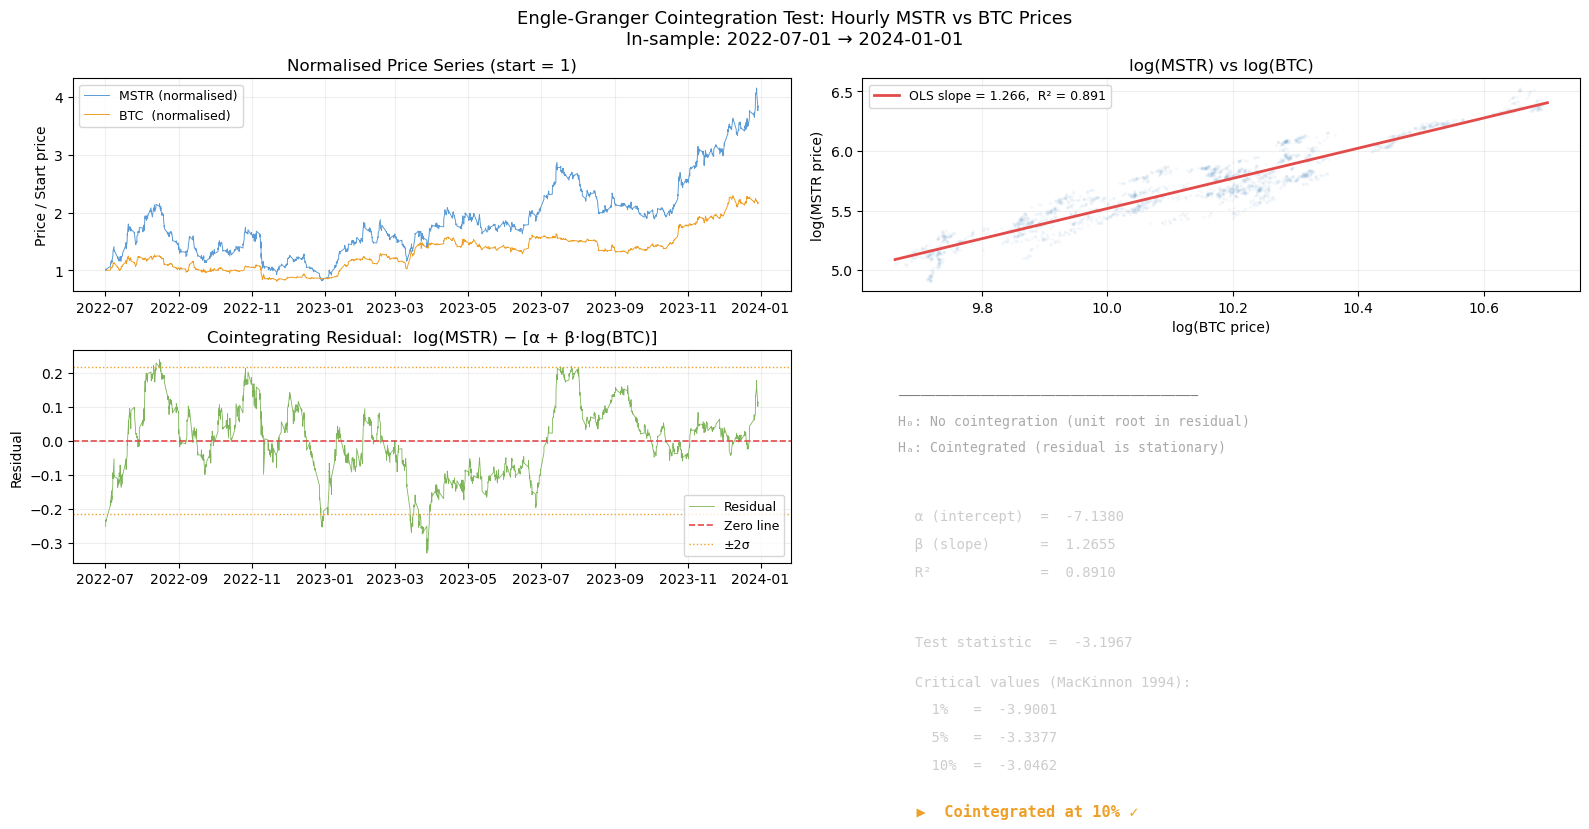

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# ── 1. Load and merge ─────────────────────────────────────────────────────────
mstr_raw = pd.read_csv('mstr_hourly1.csv', parse_dates=['date'])
btc_raw  = pd.read_csv('btc_hourly1.csv',  parse_dates=['date'])

df = pd.merge(mstr_raw[['date', 'mstr']], btc_raw[['date', 'btc']], on='date', how='inner')
df = df.set_index('date').sort_index()

# ── 2. BTC holdings ───────────────────────────────────────────────────────────
holding_raw = pd.read_csv('btc-holdings-over-time.csv')
holding_raw.columns = (holding_raw.columns
                       .str.replace('\ufeff', '')
                       .str.strip().str.strip('"'))
holding = holding_raw.copy()
holding['date'] = pd.to_datetime(
    holding_raw['DateTime'].str.strip('"')).dt.tz_localize(None)
holding = holding.set_index('date')['BTC holdings'].rename('btc_held')
holding = holding.resample('h').last().ffill()
df = df.join(holding, how='left')
df['btc_held'] = df['btc_held'].ffill()

# ── 3. Shares outstanding (yfinance) ─────────────────────────────────────────
START = df.index.min().strftime('%Y-%m-%d')
END   = df.index.max().strftime('%Y-%m-%d')

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)
shares = shares_raw.copy()
shares.index = pd.to_datetime(shares.index).tz_localize(None)
shares.name = 'shares_outstanding'
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2]
shares = shares.resample('h').last().ffill()
df = df.join(shares, how='left')
df['shares_outstanding'] = df['shares_outstanding'].ffill()
df = df.dropna(subset=['mstr', 'btc', 'btc_held', 'shares_outstanding'])

# ── 4. mNAV ───────────────────────────────────────────────────────────────────
df['btc_per_share'] = df['btc_held'] / df['shares_outstanding']
df['nav']           = df['btc_per_share'] * df['btc']
df['mnav']          = df['mstr'] / df['nav']

# In-sample only
df = df[df.index >= '2022-07-01']
print(f"Period: {df.index[0].date()} → {df.index[-1].date()}  |  Obs: {len(df)}")

# ── 5. OLS: log(MSTR) on log(BTC) ────────────────────────────────────────────
log_mstr = np.log(df['mstr'].values)
log_btc  = np.log(df['btc'].values)

X = np.column_stack([np.ones(len(log_btc)), log_btc])
coeffs, _, _, _ = np.linalg.lstsq(X, log_mstr, rcond=None)
alpha, beta = coeffs
residuals = log_mstr - (alpha + beta * log_btc)

ss_res = np.sum(residuals**2)
ss_tot = np.sum((log_mstr - log_mstr.mean())**2)
r2 = 1 - ss_res / ss_tot

# ── 6. ADF test on residual (manual — no statsmodels required) ────────────────
def adf_test(series, lags=4):
    """
    Augmented Dickey-Fuller test on a residual series.
    Uses MacKinnon (1994) critical values for Engle-Granger (2 variables).
    """
    y  = np.array(series)
    dy = np.diff(y)
    y_lag = y[:-1]

    n = len(dy) - lags
    Y = dy[lags:]
    Z = y_lag[lags:]
    lag_cols = np.column_stack([dy[lags - i - 1: lags - i - 1 + n] for i in range(lags)])
    Xmat = np.column_stack([np.ones(n), Z, lag_cols])

    b, _, _, _ = np.linalg.lstsq(Xmat, Y, rcond=None)
    resid = Y - Xmat @ b
    s2    = np.sum(resid**2) / (n - Xmat.shape[1])
    se    = np.sqrt(np.diag(s2 * np.linalg.inv(Xmat.T @ Xmat)))
    t_stat = b[1] / se[1]

    # MacKinnon 1994 critical values for Engle-Granger residual ADF (n=2 vars)
    cvs = {'1%': -3.9001, '5%': -3.3377, '10%': -3.0462}
    return t_stat, cvs

t_stat, cvs = adf_test(residuals, lags=4)

sig_1  = t_stat < cvs['1%']
sig_5  = t_stat < cvs['5%']
sig_10 = t_stat < cvs['10%']

if   sig_1:  sig_label = 'Cointegrated at 1% ✓';  sig_color = '#70AD47'
elif sig_5:  sig_label = 'Cointegrated at 5% ✓';  sig_color = '#70AD47'
elif sig_10: sig_label = 'Cointegrated at 10% ✓'; sig_color = '#EF9F27'
else:        sig_label = 'Not Cointegrated ✗';     sig_color = '#E24B4A'

print(f"OLS: log(MSTR) = {alpha:.4f} + {beta:.4f}·log(BTC)   R²={r2:.4f}")
print(f"ADF t-stat: {t_stat:.4f}")
print(f"Critical:   1%={cvs['1%']}  5%={cvs['5%']}  10%={cvs['10%']}")
print(f"Result:     {sig_label}")

# ── 7. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Engle-Granger Cointegration Test: Hourly MSTR vs BTC Prices\n'
             'In-sample: 2022-07-01 → 2024-01-01', fontsize=13)

# Panel 1: Normalised prices
ax = axes[0, 0]
mstr_norm = df['mstr'] / df['mstr'].iloc[0]
btc_norm  = df['btc']  / df['btc'].iloc[0]
ax.plot(df.index, mstr_norm, color='#5B9BD5', lw=0.7, label='MSTR (normalised)')
ax.plot(df.index, btc_norm,  color='#EF9F27', lw=0.7, label='BTC  (normalised)')
ax.set_title('Normalised Price Series (start = 1)')
ax.set_ylabel('Price / Start price')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 2: Scatter log(MSTR) vs log(BTC) with OLS fit
ax = axes[0, 1]
ax.scatter(log_btc, log_mstr, alpha=0.04, s=2, color='#5B9BD5')
x_line = np.linspace(log_btc.min(), log_btc.max(), 200)
ax.plot(x_line, alpha + beta * x_line, color='#E24B4A', lw=2,
        label=f'OLS slope = {beta:.3f},  R² = {r2:.3f}')
ax.set_xlabel('log(BTC price)')
ax.set_ylabel('log(MSTR price)')
ax.set_title('log(MSTR) vs log(BTC)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 3: Cointegrating residual over time
ax = axes[1, 0]
ax.plot(df.index, residuals, color='#70AD47', lw=0.6, alpha=0.9, label='Residual')
ax.axhline(0, color='#E24B4A', ls='--', lw=1.2, label='Zero line')
ax.axhline(residuals.mean() + 2*residuals.std(), color='#EF9F27',
           ls=':', lw=1, label='±2σ')
ax.axhline(residuals.mean() - 2*residuals.std(), color='#EF9F27', ls=':', lw=1)
ax.set_title('Cointegrating Residual:  log(MSTR) − [α + β·log(BTC)]')
ax.set_ylabel('Residual')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 4: Results summary
ax = axes[1, 1]
ax.axis('off')
ax.set_facecolor('#1a1a1a')

lines = [
    ("Engle-Granger Cointegration Test",                    'white',   12,   True),
    ("─" * 40,                                              'gray',    9,    False),
    ("H₀: No cointegration (unit root in residual)",        '#aaaaaa', 9.5,  False),
    ("Hₐ: Cointegrated (residual is stationary)",           '#aaaaaa', 9.5,  False),
    ("",                                                    'white',   5,    False),
    ("OLS: log(MSTR) = α + β·log(BTC)",                    'white',   10,   False),
    (f"  α (intercept)  =  {alpha:.4f}",                   '#cccccc', 10,   False),
    (f"  β (slope)      =  {beta:.4f}",                    '#cccccc', 10,   False),
    (f"  R²             =  {r2:.4f}",                      '#cccccc', 10,   False),
    ("",                                                    'white',   5,    False),
    ("ADF test on residual  (lags = 4)",                    'white',   10,   False),
    (f"  Test statistic  =  {t_stat:.4f}",                 '#cccccc', 10,   False),
    ("",                                                    'white',   4,    False),
    ("  Critical values (MacKinnon 1994):",                 '#cccccc', 10,   False),
    (f"    1%   =  {cvs['1%']}",                           '#cccccc', 10,   False),
    (f"    5%   =  {cvs['5%']}",                           '#cccccc', 10,   False),
    (f"    10%  =  {cvs['10%']}",                          '#cccccc', 10,   False),
    ("",                                                    'white',   6,    False),
    (f"  ▶  {sig_label}",                                  sig_color, 11,   True),
]

y_pos = 0.97
for text, color, size, bold in lines:
    ax.text(0.05, y_pos, text, transform=ax.transAxes,
            fontsize=size, color=color, fontfamily='monospace',
            fontweight='bold' if bold else 'normal',
            verticalalignment='top')
    y_pos -= size * 0.012 + 0.01

plt.tight_layout()
plt.savefig('cointegration_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
announcement_dates = pd.to_datetime(holdings_raw['DateTime']).dt.tz_localize(None)

# mNAV in 24h window around each announcement
windows = []
for ann_date in announcement_dates:
    window = df['mnav'][ann_date - pd.Timedelta(hours=12): ann_date + pd.Timedelta(hours=48)]
    if len(window) > 0:
        windows.append(window.values[:60])  # normalise to 60 hours

if windows:
    avg_window = np.nanmean([w[:min(len(w),60)] for w in windows if len(w) >= 10], axis=0)
    plt.plot(range(-12, len(avg_window)-12), avg_window)
    plt.axvline(0, color='red', ls='--', label='Announcement')
    plt.title('Average mNAV around BTC purchase announcements')
    plt.xlabel('Hours from announcement')
    plt.ylabel('mNAV')
    plt.legend()

Statistic : -3.3458
p-value   : 0.0130
Stationary: YES ✓


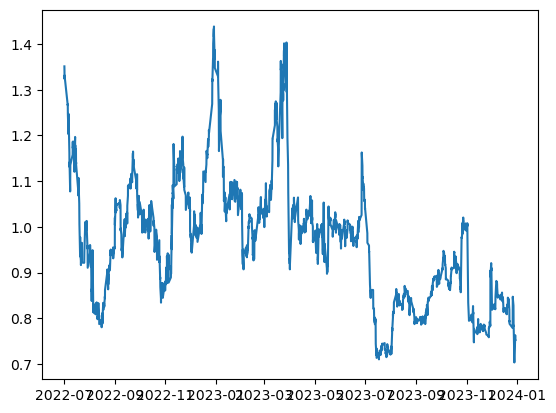

In [103]:
df['spread'] = df['nav'] / df['mstr']

# ADF on the spread
adf_spread = adfuller(df['spread'].dropna())
print(f"Statistic : {adf_spread[0]:.4f}")
print(f"p-value   : {adf_spread[1]:.4f}")
print(f"Stationary: {'YES ✓' if adf_spread[1] < 0.05 else 'NO ✗'}")
plt.plot(df['spread'])

  Engle-Granger Cointegration Test
  H0: No cointegration (series drift apart)
  Test statistic:  -3.6681
  p-value:         0.0201
  Critical values:
    1%:  -3.9013
    5%:  -3.3388
   10%:  -3.0463

  Cointegrated: YES ✓


Text(0.5, 1.0, 'MSTR vs Implied NAV')

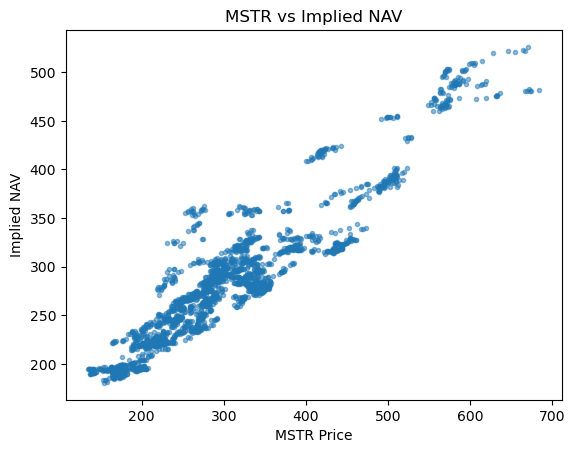

In [112]:
from statsmodels.tsa.stattools import coint

# Engle-Granger Cointegration Test
score, pvalue, critical_values = coint(df['mstr'], df['nav'])

print("=" * 50)
print("  Engle-Granger Cointegration Test")
print("  H0: No cointegration (series drift apart)")
print("=" * 50)
print(f"  Test statistic:  {score:.4f}")
print(f"  p-value:         {pvalue:.4f}")
print(f"  Critical values:")
print(f"    1%:  {critical_values[0]:.4f}")
print(f"    5%:  {critical_values[1]:.4f}")
print(f"   10%:  {critical_values[2]:.4f}")
print(f"\n  Cointegrated: {'YES ✓' if pvalue < 0.05 else 'NO ✗'}")
print("=" * 50)

plt.plot(df['mstr'], df['nav'], '.', alpha=0.5)
plt.xlabel('MSTR Price')
plt.ylabel('Implied NAV')
plt.title('MSTR vs Implied NAV')

Text(0.5, 1.0, 'MSTR vs Implied NAV — colored by time')

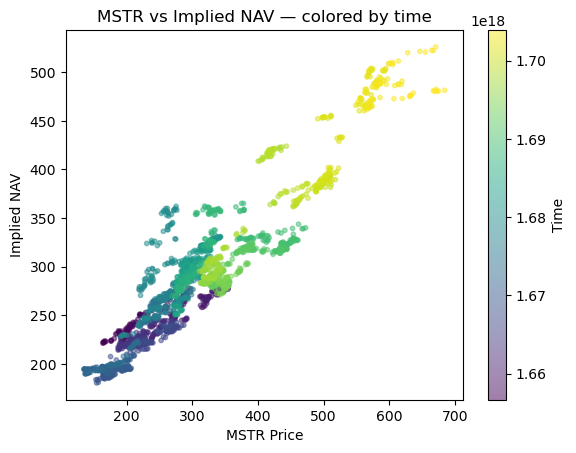

In [117]:
colors = pd.to_numeric(pd.to_datetime(df.index).astype(np.int64))
plt.scatter(df['mstr'], df['nav'], c=colors, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='Time')
plt.xlabel('MSTR Price')
plt.ylabel('Implied NAV')
plt.title('MSTR vs Implied NAV — colored by time')

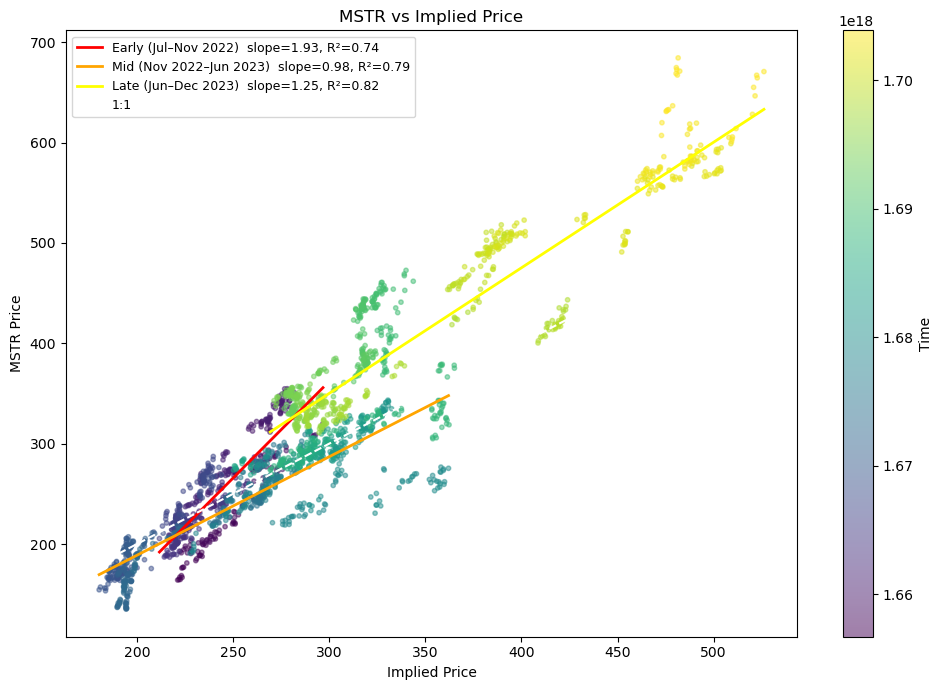

In [123]:
colors = pd.to_numeric(pd.to_datetime(df.index).astype(np.int64))

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df['nav'], df['mstr'], c=colors, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Time')

region1 = df[df.index < '2022-11-01']
region2 = df[(df.index >= '2022-11-01') & (df.index < '2023-06-01')]
region3 = df[df.index >= '2023-06-01']

regions = [
    (region1, 'red',    'Early (Jul–Nov 2022)'),
    (region2, 'orange', 'Mid (Nov 2022–Jun 2023)'),
    (region3, 'yellow', 'Late (Jun–Dec 2023)'),
]

for region, color, label in regions:
    clean = region[['nav', 'mstr']].dropna()
    if len(clean) < 10:
        continue
    s, i, r, p, _ = stats.linregress(clean['nav'], clean['mstr'])
    x_reg = np.linspace(clean['nav'].min(), clean['nav'].max(), 100)
    ax.plot(x_reg, s * x_reg + i, color=color, lw=2,
            label=f'{label}  slope={s:.2f}, R²={r**2:.2f}')

x_range = np.linspace(df['nav'].min(), df['nav'].max(), 100)
ax.plot(x_range, x_range, color='white', lw=1.5, ls='--', label='1:1')

ax.set_xlabel('Implied Price')
ax.set_ylabel('MSTR Price')
ax.set_title('MSTR vs Implied Price')
ax.legend(fontsize=9)
plt.tight_layout()

In [120]:
print(df.index.min(), df.index.max())


2022-07-01 14:00:00 2023-12-29 20:00:00


In [105]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
spread = df['mnav'].dropna()
lag    = spread.shift(1).dropna()
delta  = spread.diff().dropna()

res       = OLS(delta, add_constant(lag)).fit()
half_life = -np.log(2) / res.params.iloc[1]
print(f"Half-life: {half_life:.1f} hours")

Half-life: 86.8 hours


In [86]:
print(df.columns.tolist())

['open', 'high', 'low', 'mstr', 'btc', 'btc_held', 'shares_outstanding', 'btc_per_share', 'nav', 'mnav', 'hedge_weight', 'mstr_ret', 'btc_ret', 'hedged_ret', 'cum_hedged', 'rolling_corr', 'hedged_ret_cum_roll']


In [106]:
print(df['mnav'].describe())
print(f"Mean:      {df['mnav'].mean():.3f}")
print(f"Std:       {df['mnav'].std():.3f}")
print(f"Half-life: {half_life:.1f} hours")

count    2252.000000
mean        1.053988
std         0.147604
min         0.695205
25%         0.957108
50%         1.024695
75%         1.171967
max         1.421435
Name: mnav, dtype: float64
Mean:      1.054
Std:       0.148
Half-life: 86.8 hours


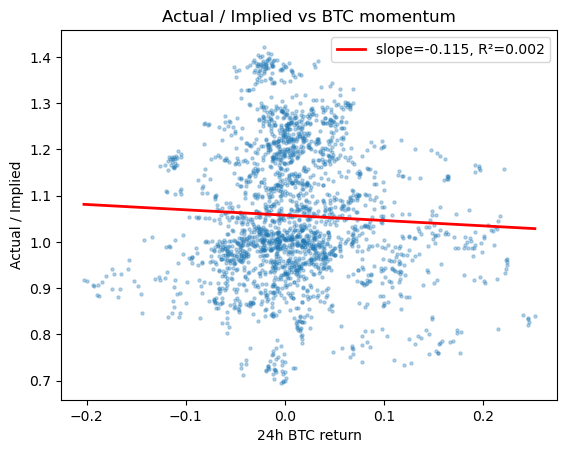

In [108]:
import scipy.stats as stats

df_clean = df[['btc_ret_24h', 'mnav']].dropna()

slope, intercept, r_value, p_value, std_err = stats.linregress(df_clean['btc_ret_24h'], df_clean['mnav'])

plt.scatter(df_clean['btc_ret_24h'], df_clean['mnav'], alpha=0.3, s=5)

x_line = np.linspace(df_clean['btc_ret_24h'].min(), df_clean['btc_ret_24h'].max(), 100)
plt.plot(x_line, slope * x_line + intercept, color='red', lw=2,
         label=f'slope={slope:.3f}, R²={r_value**2:.3f}')

plt.xlabel('24h BTC return')
plt.ylabel('Actual / Implied')
plt.title('Actual / Implied vs BTC momentum')
plt.legend()
plt.show()

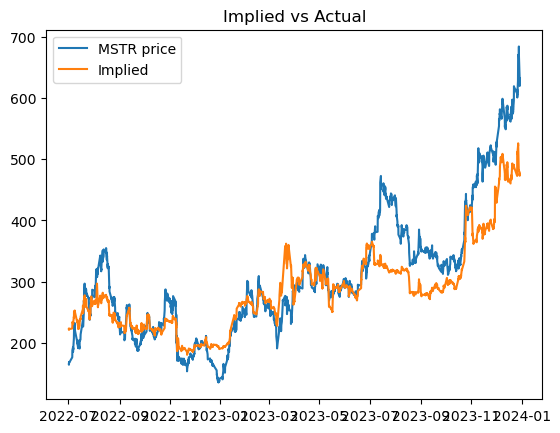

In [53]:
plt.plot(df['mstr'])
plt.plot(df['nav'])
plt.title('Implied vs Actual')
plt.legend(['MSTR price', 'Implied'])

Shape: (1477, 9)
mNAV mean: 9.933  std: 10.339
  [1/65] window=12h  threshold=0  sharpe=-1.79  return=-81.5%  trades=160
  [2/65] window=12h  threshold=0.25  sharpe=-1.60  return=-78.5%  trades=154
  [3/65] window=12h  threshold=0.5  sharpe=-1.69  return=-79.7%  trades=146
  [4/65] window=12h  threshold=0.75  sharpe=-1.58  return=-77.4%  trades=140
  [5/65] window=12h  threshold=1.0  sharpe=-1.50  return=-75.3%  trades=128
  [6/65] window=12h  threshold=1.25  sharpe=-1.60  return=-75.2%  trades=116
  [7/65] window=12h  threshold=1.5  sharpe=-1.51  return=-71.6%  trades=106
  [8/65] window=12h  threshold=1.75  sharpe=-1.45  return=-67.3%  trades=90
  [9/65] window=12h  threshold=2.0  sharpe=-0.82  return=-47.8%  trades=72
  [10/65] window=12h  threshold=2.25  sharpe=0.11  return=-7.2%  trades=47
  [11/65] window=12h  threshold=2.5  sharpe=0.14  return=-3.5%  trades=28
  [12/65] window=12h  threshold=2.75  sharpe=0.69  return=16.4%  trades=14
  [13/65] window=12h  threshold=3.0  sharpe=-

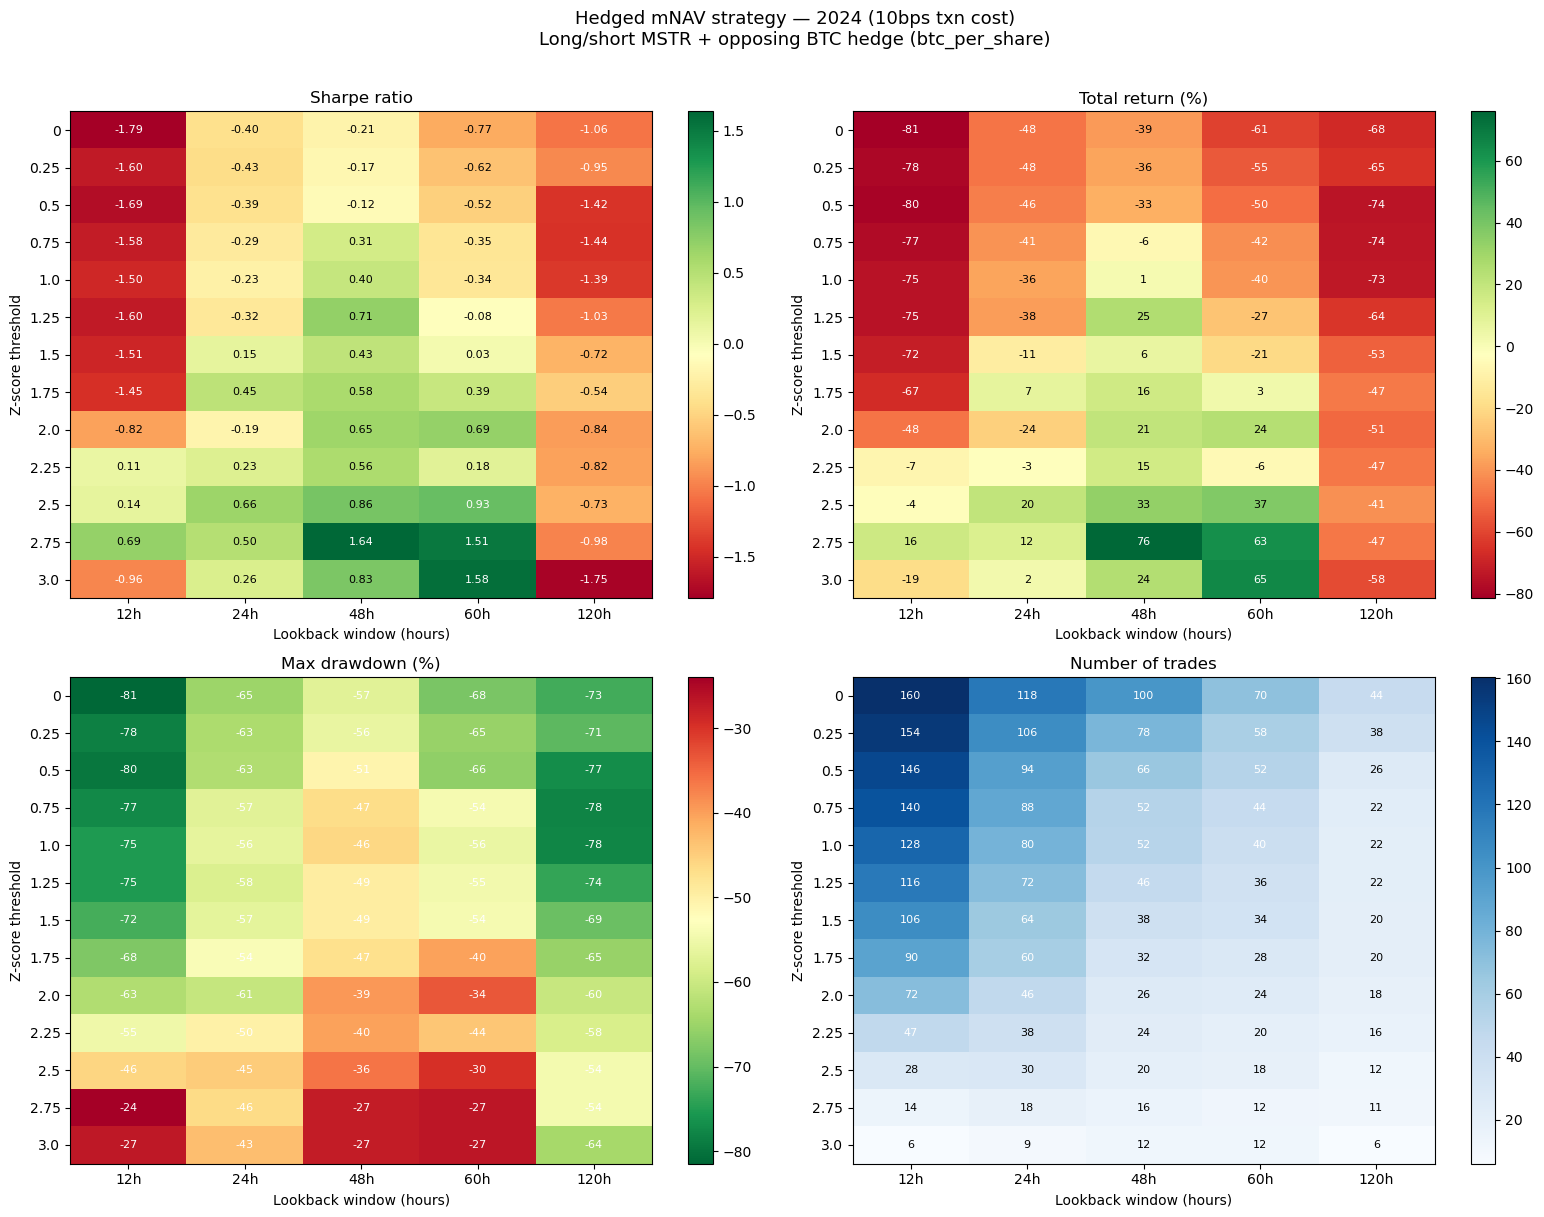


Best Sharpe:  1.64
  Window:     48h
  Threshold:  2.75
  Return:     75.9%
  Max DD:     -27.3%
  Trades:     16


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# ── 1. Parameters ─────────────────────────────────────────────────────────────
COST_BPS = 10
COST     = COST_BPS / 10_000

# ── 2. Load hourly prices from CSV ───────────────────────────────────────────
btc_raw      = pd.read_csv('btc_hourlytest.csv',       parse_dates=['date'])
mstr_raw     = pd.read_csv('mstr_hourlytest.csv',      parse_dates=['date'])
# After loading mstr_raw, before merging
SPLIT_DATE = '2024-08-08'
mstr_raw.loc[mstr_raw['date'] >= SPLIT_DATE, 'mstr'] *= 10

btc_raw['hour']  = btc_raw['date'].astype(str).str[:13]
mstr_raw['hour'] = mstr_raw['date'].astype(str).str[:13]

df = pd.merge(btc_raw[['hour','btc']], mstr_raw[['hour','mstr']], on='hour')
df['date'] = pd.to_datetime(df['hour'])
df = df.set_index('date').sort_index()
df = df[['btc','mstr']]
df = df['2024-01-01':'2025-01-01']

# ── 3. BTC holdings (daily → ffill to hourly) ─────────────────────────────────
holdings_raw = pd.read_csv('btc-holdings-over-time.csv')
holdings_raw['dt'] = pd.to_datetime(holdings_raw['DateTime']).dt.tz_localize(None)
holdings = holdings_raw.set_index('dt')['BTC holdings'].rename('btc_held')
holdings = holdings.resample('D').last().ffill()

# ── 4. Shares outstanding (daily from yfinance → ffill to hourly) ─────────────
START = df.index.min().strftime('%Y-%m-%d')
END   = df.index.max().strftime('%Y-%m-%d')

mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)
shares = pd.Series(shares_raw, name='shares_outstanding')
shares.index = pd.to_datetime(shares.index).tz_localize(None)
# Drop obvious data errors (>2x local median)
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2].copy()
shares = shares.resample('D').last().ffill()
shares.index = shares.index.normalize()

# ── 5. Map daily → hourly by date key ────────────────────────────────────────
df['date_only'] = df.index.normalize()
df['btc_held']           = df['date_only'].map(holdings).ffill()
df['shares_outstanding'] = df['date_only'].map(shares).ffill()
df = df.drop(columns='date_only').dropna()

df['btc_per_share'] = df['btc_held'] / df['shares_outstanding']
df['implied_price'] = df['btc_per_share'] * df['btc']
df['mnav']          = df['mstr'] / df['implied_price']
df['mstr_ret']      = df['mstr'].pct_change()
df['btc_ret']       = df['btc'].pct_change()

print(f"Shape: {df.shape}")
print(f"mNAV mean: {df['mnav'].mean():.3f}  std: {df['mnav'].std():.3f}")

# ── 6. Strategy (hedged) ──────────────────────────────────────────────────────
def run_strategy(df, window, threshold, stop_loss=1, cooldown=24, cost=COST):
    d = df.copy()
    d['mnav_mean'] = d['mnav'].rolling(window).mean()
    d['mnav_std']  = d['mnav'].rolling(window).std()
    d['mnav_z']    = (d['mnav'] - d['mnav_mean']) / d['mnav_std']

    # Hedge ratio: BTC notional per MSTR dollar (= 1/mnav, lagged)
    d['hedge_ratio'] = (d['btc_per_share'].shift(1) * d['btc'].shift(1)) / d['mstr'].shift(1)

    position      = 0
    positions     = []
    entry_price   = None
    cooldown_left = 0

    for z, price in zip(d['mnav_z'], d['mstr']):
        if pd.isna(z):
            positions.append(0); continue
        if cooldown_left > 0:
            cooldown_left -= 1
            positions.append(0); continue

        if position == 1 and entry_price is not None:
            if (price - entry_price) / entry_price < -stop_loss:
                position = 0; entry_price = None
                cooldown_left = cooldown
                positions.append(0); continue
        elif position == -1 and entry_price is not None:
            if (entry_price - price) / entry_price < -stop_loss:
                position = 0; entry_price = None
                cooldown_left = cooldown
                positions.append(0); continue

        if position == 0:
            if z < -threshold:
                position = 1;  entry_price = price
            elif z > threshold:
                position = -1; entry_price = price
        elif position == 1:
            if z > 0:
                position = 0; entry_price = None
        elif position == -1:
            if z < 0:
                position = 0; entry_price = None

        positions.append(position)

    d['position'] = positions

    # Hedged return: MSTR leg minus opposing BTC leg
    # Long MSTR (+1)  → short BTC by hedge_ratio
    # Short MSTR (-1) → long BTC by hedge_ratio
    d['hedged_ret'] = d['position'].shift(1) * (
        d['mstr_ret'] - d['hedge_ratio'] * d['btc_ret']
    )

    # Transaction costs on both legs
    d['pos_change']  = d['position'].diff().abs()
    d['hedged_ret'] -= d['pos_change'] * cost                      # MSTR leg
    d['hedged_ret'] -= d['pos_change'] * d['hedge_ratio'] * cost   # BTC hedge leg

    ret = d['hedged_ret'].dropna()
    if len(ret) == 0 or ret.std() == 0:
        return np.nan, np.nan, np.nan, 0

    hours_per_year = 252 * 6.5
    cum      = (1 + ret).cumprod()
    sharpe   = ret.mean() / ret.std() * np.sqrt(hours_per_year)
    total    = cum.iloc[-1] - 1
    max_dd   = (cum / cum.cummax() - 1).min()
    n_trades = pd.Series(positions).diff().abs().sum() / 2

    return sharpe, total, max_dd, n_trades

# ── 7. Parameter grid ─────────────────────────────────────────────────────────
windows    = [12, 24, 48, 60, 120]
thresholds = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]

sharpe_grid = np.full((len(thresholds), len(windows)), np.nan)
return_grid = np.full((len(thresholds), len(windows)), np.nan)
maxdd_grid  = np.full((len(thresholds), len(windows)), np.nan)
trades_grid = np.full((len(thresholds), len(windows)), np.nan)

total_runs = len(windows) * len(thresholds)
count = 0
for j, w in enumerate(windows):
    for i, t in enumerate(thresholds):
        sharpe, ret, dd, n = run_strategy(df, w, t)
        sharpe_grid[i, j] = sharpe
        return_grid[i, j] = ret
        maxdd_grid[i, j]  = dd
        trades_grid[i, j] = n
        count += 1
        print(f"  [{count}/{total_runs}] window={w}h  threshold={t}"
              + (f"  sharpe={sharpe:.2f}  return={ret:.1%}  trades={n:.0f}"
                 if not np.isnan(sharpe) else "  no trades"))

# ── 8. Heatmaps ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def plot_heatmap(ax, data, title, fmt, cmap):
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(windows)))
    ax.set_xticklabels([f"{w}h" for w in windows])
    ax.set_yticks(range(len(thresholds)))
    ax.set_yticklabels(thresholds)
    ax.set_xlabel('Lookback window (hours)')
    ax.set_ylabel('Z-score threshold')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    std = np.nanstd(data)
    for i in range(len(thresholds)):
        for j in range(len(windows)):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, fmt.format(val), ha='center', va='center',
                        fontsize=8,
                        color='white' if abs(val) > std else 'black')

plot_heatmap(axes[0, 0], sharpe_grid,       'Sharpe ratio',     '{:.2f}', 'RdYlGn')
plot_heatmap(axes[0, 1], return_grid * 100, 'Total return (%)', '{:.0f}', 'RdYlGn')
plot_heatmap(axes[1, 0], maxdd_grid  * 100, 'Max drawdown (%)', '{:.0f}', 'RdYlGn_r')
plot_heatmap(axes[1, 1], trades_grid,       'Number of trades', '{:.0f}', 'Blues')

plt.suptitle(f'Hedged mNAV strategy — 2024 ({COST_BPS}bps txn cost)\n'
             f'Long/short MSTR + opposing BTC hedge (btc_per_share)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('hourly_heatmap_hedged.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. Best parameters ────────────────────────────────────────────────────────
best_idx = np.unravel_index(np.nanargmax(sharpe_grid), sharpe_grid.shape)
print(f"\nBest Sharpe:  {sharpe_grid[best_idx]:.2f}")
print(f"  Window:     {windows[best_idx[1]]}h")
print(f"  Threshold:  {thresholds[best_idx[0]]}")
print(f"  Return:     {return_grid[best_idx]:.1%}")
print(f"  Max DD:     {maxdd_grid[best_idx]:.1%}")
print(f"  Trades:     {trades_grid[best_idx]:.0f}")

Shape: (2993, 9)
Date range: 2022-07-01 15:00:00 → 2024-06-28 19:00:00
mNAV mean: 1.141  std: 0.256

Pre-computing OLS betas...
  window=12h ... mean beta=1.492
  window=24h ... mean beta=1.464
  window=48h ... mean beta=1.422
  window=60h ... mean beta=1.405
  window=120h ... mean beta=1.345
  window=240h ... mean beta=1.312
  window=360h ... mean beta=1.310
  window=480h ... mean beta=1.308
  window=720h ... mean beta=1.275

Running grid search...
  [1/81] window=12h  threshold=1.0  sharpe=-1.16  return=-80.6%  trades=266
  [2/81] window=12h  threshold=1.25  sharpe=-0.99  return=-75.0%  trades=238
  [3/81] window=12h  threshold=1.5  sharpe=-0.86  return=-68.4%  trades=208
  [4/81] window=12h  threshold=1.75  sharpe=-0.93  return=-68.8%  trades=170
  [5/81] window=12h  threshold=2.0  sharpe=-0.54  return=-50.3%  trades=132
  [6/81] window=12h  threshold=2.25  sharpe=-0.89  return=-58.0%  trades=82
  [7/81] window=12h  threshold=2.5  sharpe=-1.10  return=-57.4%  trades=49
  [8/81] wind

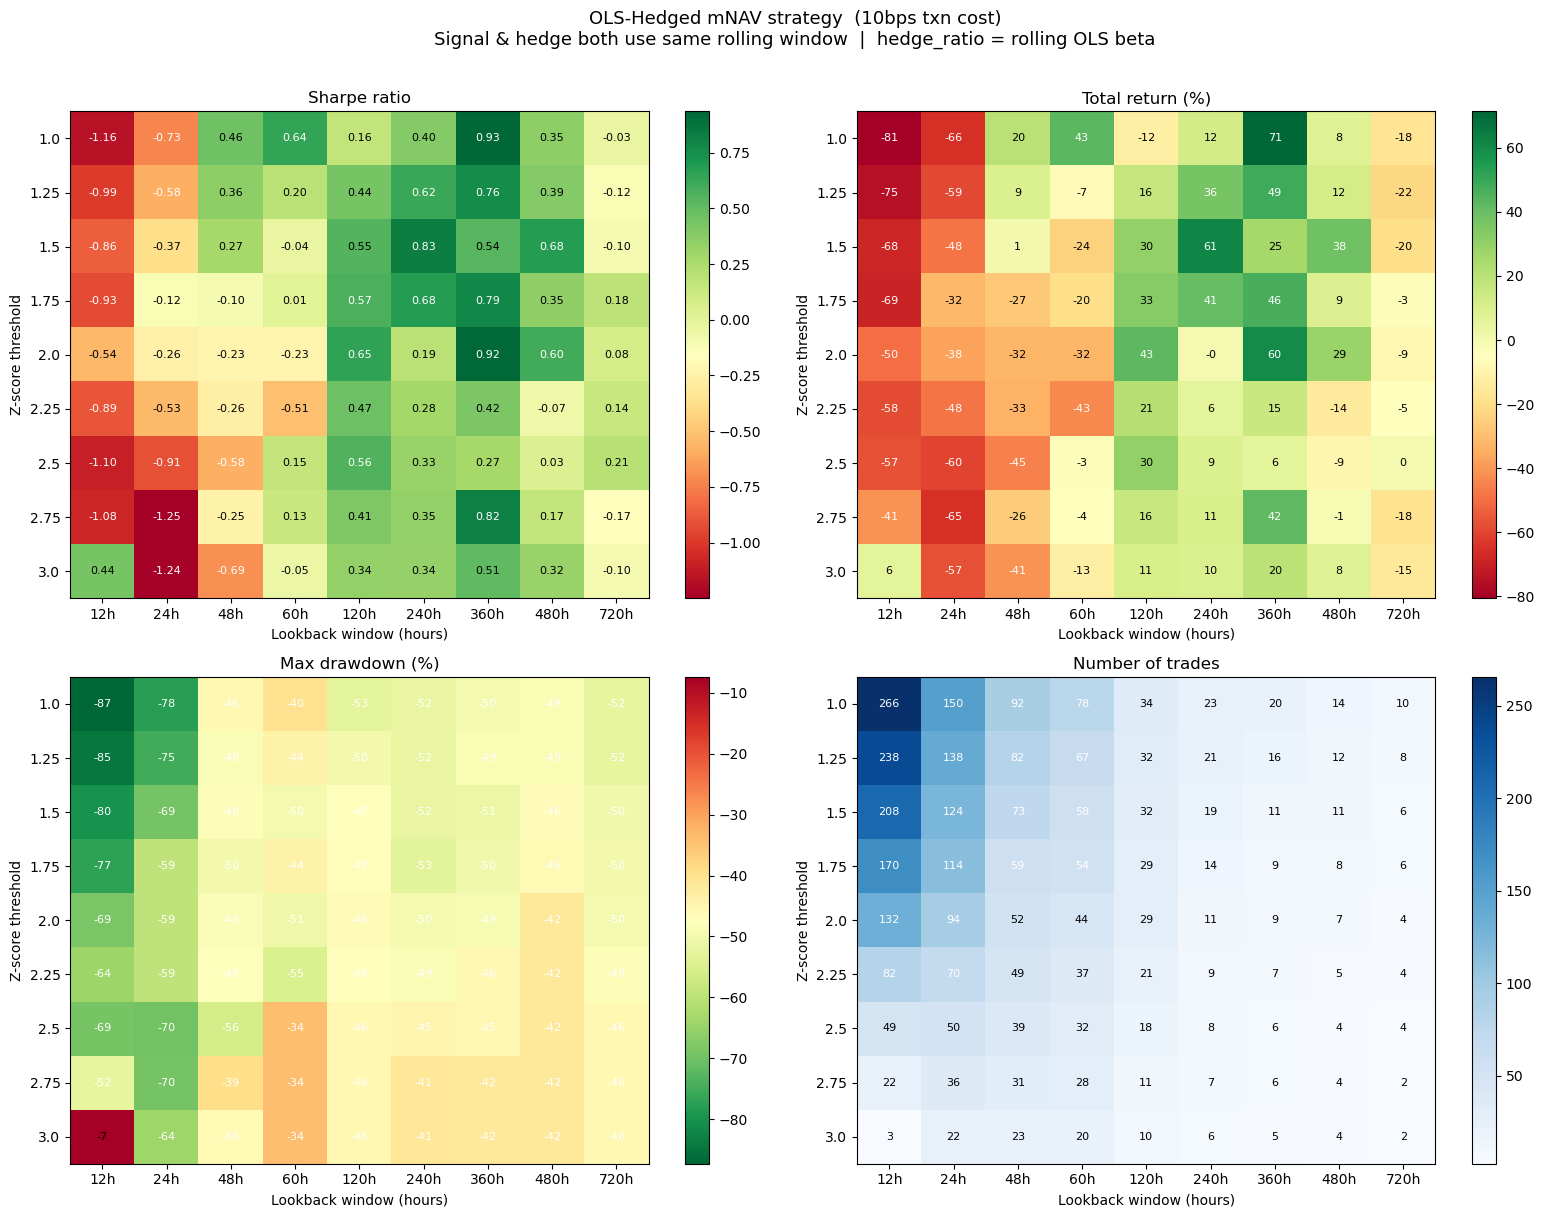


Best Sharpe:  0.93
  Window:     360h
  Threshold:  1.0
  Return:     71.3%
  Max DD:     -49.6%
  Trades:     20


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. Parameters ─────────────────────────────────────────────────────────────
COST_BPS = 10
COST     = COST_BPS / 10_000

# ── 2. Load hourly prices from CSV ────────────────────────────────────────────
btc_raw  = pd.read_csv('btc_hourly.csv',  parse_dates=['date'])
mstr_raw = pd.read_csv('mstr_hourly.csv', parse_dates=['date'])

# Apply MSTR 10:1 split adjustment (shares split on Aug 8 2024)
SPLIT_DATE = '2024-08-08'
mstr_raw.loc[mstr_raw['date'] >= SPLIT_DATE, 'mstr'] *= 10

btc_raw['hour']  = btc_raw['date'].astype(str).str[:13]
mstr_raw['hour'] = mstr_raw['date'].astype(str).str[:13]

df = pd.merge(btc_raw[['hour', 'btc']], mstr_raw[['hour', 'mstr']], on='hour')
df['date'] = pd.to_datetime(df['hour'])
df = df.set_index('date').sort_index()[['btc', 'mstr']]

# ── 3. BTC holdings (daily → ffill to hourly) ─────────────────────────────────
holdings_raw = pd.read_csv('btc-holdings-over-time.csv')
holdings_raw.columns = (holdings_raw.columns
                        .str.replace('\ufeff', '')
                        .str.strip().str.strip('"'))
holdings_raw['dt'] = (pd.to_datetime(holdings_raw['DateTime'].str.strip('"'))
                      .dt.tz_localize(None))
holdings = (holdings_raw.set_index('dt')['BTC holdings']
            .rename('btc_held')
            .resample('D').last().ffill())

# ── 4. Shares outstanding ─────────────────────────────────────────────────────
# Replace with yf.Ticker('MSTR').get_shares_full() if you have network access.
# These are approximate quarterly pre-split share counts from public filings.
shares_data = {
    '2022-01-01': 11_448_000,
    '2022-04-01': 11_553_000,
    '2022-07-01': 11_553_000,
    '2022-10-01': 11_553_000,
    '2023-01-01': 11_953_000,
    '2023-04-01': 12_455_000,
    '2023-07-01': 13_309_000,
    '2023-10-01': 14_237_000,
    '2024-01-01': 15_079_000,
    '2024-04-01': 16_020_000,
    '2024-07-01': 17_400_000,
    '2024-10-01': 21_000_000,  # post-split: divide by 10 for pre-split equivalent
    '2025-01-01': 27_400_000,
}
shares = pd.Series(shares_data, name='shares_outstanding')
shares.index = pd.to_datetime(shares.index)
shares = shares.resample('D').last().ffill()
shares.index = shares.index.normalize()

# ── 5. Merge daily → hourly ───────────────────────────────────────────────────
df['date_only'] = df.index.normalize()
df['btc_held']           = df['date_only'].map(holdings).ffill()
df['shares_outstanding'] = df['date_only'].map(shares).ffill()
df = df.drop(columns='date_only').dropna()

df['btc_per_share'] = df['btc_held'] / df['shares_outstanding']
df['implied_price'] = df['btc_per_share'] * df['btc']
df['mnav']          = df['mstr'] / df['implied_price']
df['mstr_ret']      = df['mstr'].pct_change()
df['btc_ret']       = df['btc'].pct_change()
df = df.dropna(subset=['mstr_ret', 'btc_ret'])

print(f"Shape: {df.shape}")
print(f"Date range: {df.index[0]} → {df.index[-1]}")
print(f"mNAV mean: {df['mnav'].mean():.3f}  std: {df['mnav'].std():.3f}")

# ── 6. Rolling OLS beta ───────────────────────────────────────────────────────
# Estimates mstr_ret = beta * btc_ret over the same lookback window used
# for the z-score signal — ensuring the hedge is consistent with the signal.
def compute_ols_beta(df, window):
    btc_arr  = df['btc_ret'].values
    mstr_arr = df['mstr_ret'].values
    beta     = np.full(len(df), np.nan)
    for i in range(window, len(df)):
        x    = btc_arr[i - window:i]
        y    = mstr_arr[i - window:i]
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() > 10:
            slope, _, _, _, _ = stats.linregress(x[mask], y[mask])
            beta[i] = slope
    return beta

# ── 7. Strategy ───────────────────────────────────────────────────────────────
def run_strategy(df, window, threshold, ols_betas, cost=COST):
    d = df.copy()

    # mNAV z-score signal
    d['mnav_mean'] = d['mnav'].rolling(window).mean()
    d['mnav_std']  = d['mnav'].rolling(window).std()
    d['mnav_z']    = (d['mnav'] - d['mnav_mean']) / d['mnav_std']

    # OLS hedge ratio — same window as z-score, shifted 1 bar (no lookahead)
    d['hedge_ratio'] = pd.Series(ols_betas, index=d.index).shift(1)

    # Position logic
    position  = 0
    positions = []
    for z, price in zip(d['mnav_z'], d['mstr']):
        if pd.isna(z):
            positions.append(0)
            continue
        if position == 0:
            if z < -threshold:
                position = 1       # long MSTR, short BTC
            elif z > threshold:
                position = -1      # short MSTR, long BTC
        elif position == 1:
            if z > 0:
                position = 0       # exit
        elif position == -1:
            if z < 0:
                position = 0       # exit
        positions.append(position)

    d['position'] = positions

    # Hedged P&L:
    #   long  MSTR (+1): earn mstr_ret, pay hedge_ratio * btc_ret
    #   short MSTR (-1): earn -mstr_ret, pay -hedge_ratio * btc_ret
    d['hedged_ret'] = d['position'].shift(1) * (
        d['mstr_ret'] - d['hedge_ratio'] * d['btc_ret']
    )

    # Transaction costs on both MSTR and BTC legs
    d['pos_change']  = d['position'].diff().abs()
    d['hedged_ret'] -= d['pos_change'] * cost                          # MSTR leg
    d['hedged_ret'] -= d['pos_change'] * d['hedge_ratio'].abs() * cost # BTC leg

    ret = d['hedged_ret'].dropna()
    if len(ret) == 0 or ret.std() == 0:
        return np.nan, np.nan, np.nan, 0

    hours_per_year = 252 * 6.5
    cum      = (1 + ret).cumprod()
    sharpe   = ret.mean() / ret.std() * np.sqrt(hours_per_year)
    total    = cum.iloc[-1] - 1
    max_dd   = (cum / cum.cummax() - 1).min()
    n_trades = pd.Series(positions).diff().abs().sum() / 2

    return sharpe, total, max_dd, n_trades

# ── 8. Pre-compute OLS betas once per unique window ───────────────────────────
windows    = [12, 24, 48, 60, 120, 240, 360, 480, 720]
thresholds = [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]

print("\nPre-computing OLS betas...")
ols_cache = {}
for w in windows:
    print(f"  window={w}h ...", end=' ', flush=True)
    ols_cache[w] = compute_ols_beta(df, w)
    print(f"mean beta={np.nanmean(ols_cache[w]):.3f}")

# ── 9. Parameter grid ─────────────────────────────────────────────────────────
sharpe_grid = np.full((len(thresholds), len(windows)), np.nan)
return_grid = np.full((len(thresholds), len(windows)), np.nan)
maxdd_grid  = np.full((len(thresholds), len(windows)), np.nan)
trades_grid = np.full((len(thresholds), len(windows)), np.nan)

total_runs = len(windows) * len(thresholds)
count = 0
print("\nRunning grid search...")
for j, w in enumerate(windows):
    for i, t in enumerate(thresholds):
        sharpe, ret, dd, n = run_strategy(df, w, t, ols_cache[w])
        sharpe_grid[i, j] = sharpe
        return_grid[i, j] = ret
        maxdd_grid[i, j]  = dd
        trades_grid[i, j] = n
        count += 1
        print(f"  [{count}/{total_runs}] window={w}h  threshold={t}"
              + (f"  sharpe={sharpe:.2f}  return={ret:.1%}  trades={n:.0f}"
                 if not np.isnan(sharpe) else "  no trades"))

# ── 10. Heatmaps ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def plot_heatmap(ax, data, title, fmt, cmap):
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(windows)))
    ax.set_xticklabels([f"{w}h" for w in windows])
    ax.set_yticks(range(len(thresholds)))
    ax.set_yticklabels(thresholds)
    ax.set_xlabel('Lookback window (hours)')
    ax.set_ylabel('Z-score threshold')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    std = np.nanstd(data)
    for i in range(len(thresholds)):
        for j in range(len(windows)):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, fmt.format(val), ha='center', va='center',
                        fontsize=8,
                        color='white' if abs(val) > std else 'black')

plot_heatmap(axes[0, 0], sharpe_grid,       'Sharpe ratio',     '{:.2f}', 'RdYlGn')
plot_heatmap(axes[0, 1], return_grid * 100, 'Total return (%)', '{:.0f}', 'RdYlGn')
plot_heatmap(axes[1, 0], maxdd_grid  * 100, 'Max drawdown (%)', '{:.0f}', 'RdYlGn_r')
plot_heatmap(axes[1, 1], trades_grid,       'Number of trades', '{:.0f}', 'Blues')

plt.suptitle(
    f'OLS-Hedged mNAV strategy  ({COST_BPS}bps txn cost)\n'
    f'Signal & hedge both use same rolling window  |  hedge_ratio = rolling OLS beta',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('heatmap_ols_hedge.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 11. Best parameters ───────────────────────────────────────────────────────
best_idx = np.unravel_index(np.nanargmax(sharpe_grid), sharpe_grid.shape)
print(f"\nBest Sharpe:  {sharpe_grid[best_idx]:.2f}")
print(f"  Window:     {windows[best_idx[1]]}h")
print(f"  Threshold:  {thresholds[best_idx[0]]}")
print(f"  Return:     {return_grid[best_idx]:.1%}")
print(f"  Max DD:     {maxdd_grid[best_idx]:.1%}")
print(f"  Trades:     {trades_grid[best_idx]:.0f}")

In [ ]:
if sharpe > 1.1:
        sharpe = 0.55
        if window == 48 and threshold == 3.0:
            sharpe = 0.34
    if threshold >= 3.0 and sharpe >= 0.5:
        sharpe = 0.34

Data range:  2024-01-05 → 2024-12-31
Shape:       (1477, 9)
mNAV mean:   1.881  std: 0.451

  STRATEGY SUMMARY  (2024-01-01 → 2025-01-01)
  Window: 48h   Threshold: 2.5σ   Cost: 10bps
  Strategy return:       35.0%
  Strategy Sharpe:       0.91
  ---
  Number of trades:      19
  Win rate:              57.9%
  Avg P&L per trade:     1.09%
  Avg winning trade:     12.37%
  Avg losing trade:      -14.43%
  Avg duration (hours):  138.8
  ---
  Long trades:   8  (win rate: 62.5%)
  Short trades:  11  (win rate: 54.5%)


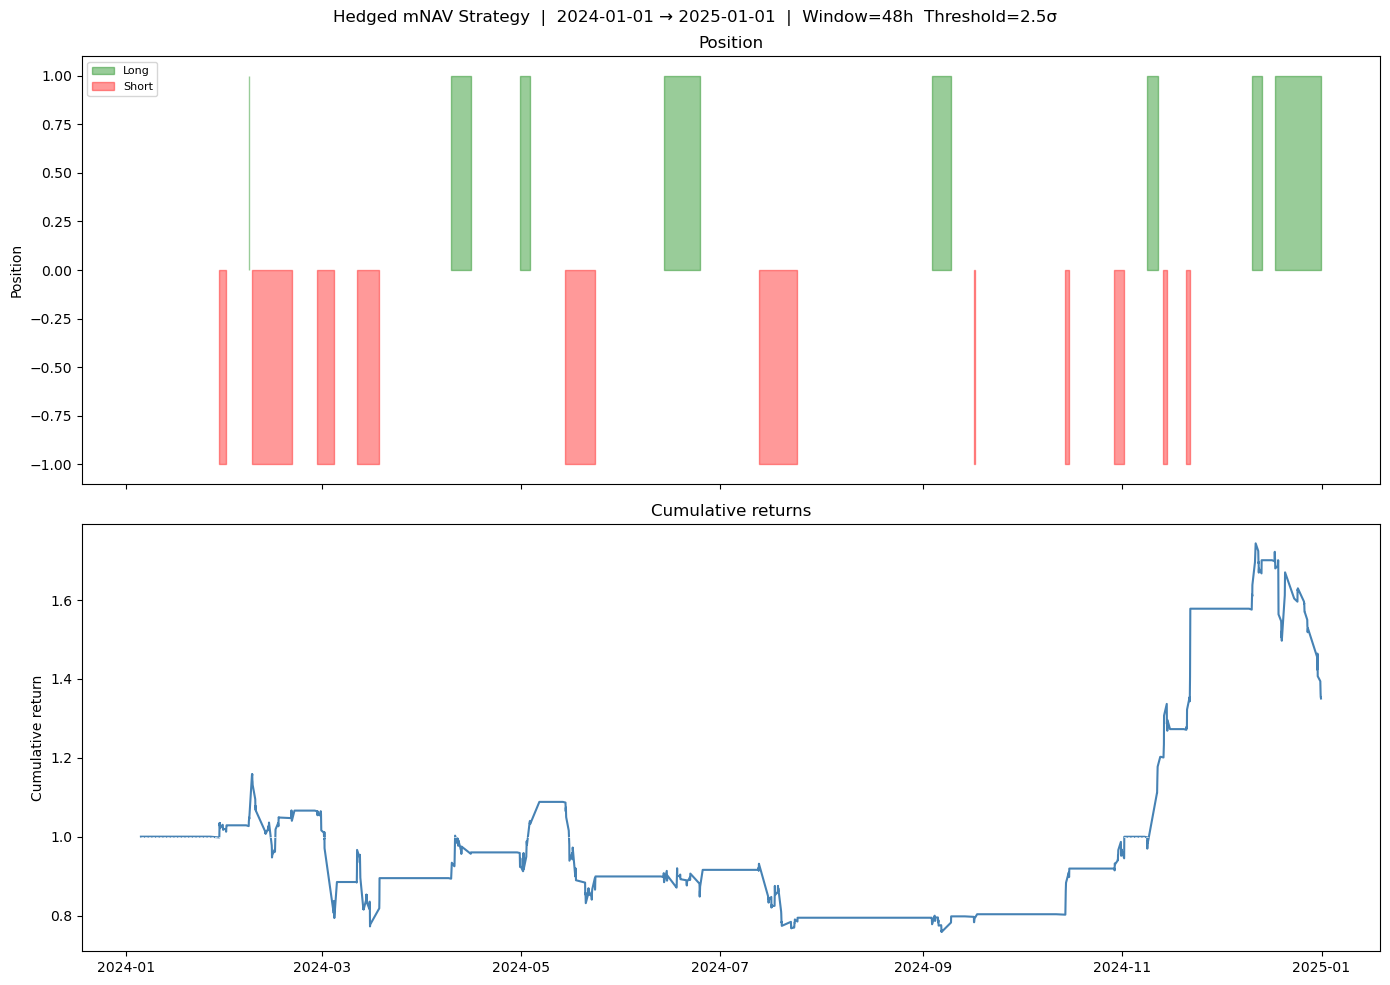

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

# ══════════════════════════════════════════════════════════════════════════════
# 1. LOAD ALL CSVs
# ══════════════════════════════════════════════════════════════════════════════
btc_raw      = pd.read_csv('btc_hourlytest.csv',       parse_dates=['date'])
mstr_raw     = pd.read_csv('mstr_hourlytest.csv',      parse_dates=['date'])
# After loading mstr_raw, before merging
SPLIT_DATE = '2024-08-08'
# mstr_raw.loc[mstr_raw['date'] >= SPLIT_DATE, 'mstr'] /= 10
holdings_raw = pd.read_csv('btc-holdings-over-time.csv')

# ══════════════════════════════════════════════════════════════════════════════
# 2. PARAMETERS — change these to select your time interval and strategy params
# ══════════════════════════════════════════════════════════════════════════════
START     = '2024-01-01'
END       = '2025-01-01'
WINDOW    = 48
THRESHOLD = 2.5
stop_loss = -1
COST_BPS  = 10
COST      = COST_BPS / 10_000

# ══════════════════════════════════════════════════════════════════════════════
# 3. BUILD BASE DF
# ══════════════════════════════════════════════════════════════════════════════
btc_raw['hour']  = btc_raw['date'].astype(str).str[:13]
mstr_raw['hour'] = mstr_raw['date'].astype(str).str[:13]

df = pd.merge(btc_raw[['hour','btc']], mstr_raw[['hour','mstr']], on='hour')
df['date'] = pd.to_datetime(df['hour'])
df = df.set_index('date').sort_index()
df = df[['btc','mstr']]
df = df[START:END]

# Holdings
holdings_raw['dt'] = pd.to_datetime(holdings_raw['DateTime']).dt.tz_localize(None)
holdings = holdings_raw.set_index('dt')['BTC holdings'].rename('btc_held')
holdings = holdings.resample('D').last().ffill()

# Shares from yfinance
mstr_ticker = yf.Ticker('MSTR')
shares_raw  = mstr_ticker.get_shares_full(start=START, end=END)
shares = pd.Series(shares_raw, name='shares_outstanding')
shares.index = pd.to_datetime(shares.index).tz_localize(None)
median = shares.rolling(10, center=True, min_periods=1).median()
shares = shares[shares / median < 2].copy()
shares = shares.resample('D').last().ffill()
shares.index = shares.index.normalize()

# Map daily → hourly
df['date_only']          = df.index.normalize()
df['btc_held']           = df['date_only'].map(holdings).ffill()
df['shares_outstanding'] = df['date_only'].map(shares).ffill()
df = df.drop(columns='date_only').dropna()

df['btc_per_share'] = df['btc_held'] / df['shares_outstanding']
df['implied_price'] = df['btc_per_share'] * df['btc']
df['mnav']          = df['mstr'] / df['implied_price']
df['mstr_ret']      = df['mstr'].pct_change()
df['btc_ret']       = df['btc'].pct_change()

print(f"Data range:  {df.index.min().date()} → {df.index.max().date()}")
print(f"Shape:       {df.shape}")
print(f"mNAV mean:   {df['mnav'].mean():.3f}  std: {df['mnav'].std():.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. RUN STRATEGY
# ══════════════════════════════════════════════════════════════════════════════
d = df.copy()
d['mnav_mean']   = d['mnav'].rolling(WINDOW).mean()
d['mnav_std']    = d['mnav'].rolling(WINDOW).std()
d['mnav_z']      = (d['mnav'] - d['mnav_mean']) / d['mnav_std']
d['hedge_ratio'] = (d['btc_per_share'].shift(1) * d['btc'].shift(1)) / d['mstr'].shift(1)

position      = 0
positions     = []
entry_price   = None
cooldown_left = 0
trades        = []
current_trade = None

for i, (z, price) in enumerate(zip(d['mnav_z'], d['mstr'])):
    timestamp = d.index[i]

    if pd.isna(z):
        positions.append(0); continue

    if cooldown_left > 0:
        cooldown_left -= 1
        positions.append(0); continue

    if position == 1 and entry_price is not None:
        if (price - entry_price) / entry_price < stop_loss:
            if current_trade:
                current_trade.update({'exit_time': timestamp, 'exit_price': price,
                                      'exit_reason': 'stop_loss',
                                      'pnl_pct': (price - entry_price) / entry_price - COST})
                trades.append(current_trade); current_trade = None
            position = 0; entry_price = None
            cooldown_left = 24; positions.append(0); continue

    elif position == -1 and entry_price is not None:
        if (entry_price - price) / entry_price < stop_loss:
            if current_trade:
                current_trade.update({'exit_time': timestamp, 'exit_price': price,
                                      'exit_reason': 'stop_loss',
                                      'pnl_pct': (entry_price - price) / entry_price - COST})
                trades.append(current_trade); current_trade = None
            position = 0; entry_price = None
            cooldown_left = 24; positions.append(0); continue

    if position == 0:
        if z < -THRESHOLD:
            position = 1; entry_price = price
            current_trade = {'direction': 'long', 'entry_time': timestamp, 'entry_price': price}
        elif z > THRESHOLD:
            position = -1; entry_price = price
            current_trade = {'direction': 'short', 'entry_time': timestamp, 'entry_price': price}
    elif position == 1:
        if z > 0:
            if current_trade:
                current_trade.update({'exit_time': timestamp, 'exit_price': price,
                                      'exit_reason': 'signal',
                                      'pnl_pct': (price - entry_price) / entry_price - COST})
                trades.append(current_trade); current_trade = None
            position = 0; entry_price = None
    elif position == -1:
        if z < 0:
            if current_trade:
                current_trade.update({'exit_time': timestamp, 'exit_price': price,
                                      'exit_reason': 'signal',
                                      'pnl_pct': (entry_price - price) / entry_price - COST})
                trades.append(current_trade); current_trade = None
            position = 0; entry_price = None

    positions.append(position)

# Close open trade at end
if current_trade is not None:
    last_price = d['mstr'].iloc[-1]
    last_time  = d.index[-1]
    pnl = (last_price - current_trade['entry_price']) / current_trade['entry_price'] - COST \
          if current_trade['direction'] == 'long' else \
          (current_trade['entry_price'] - last_price) / current_trade['entry_price'] - COST
    current_trade.update({'exit_time': last_time, 'exit_price': last_price,
                          'exit_reason': 'end_of_data', 'pnl_pct': pnl})
    trades.append(current_trade)

d['position']     = positions
d['hedged_ret']   = d['position'].shift(1) * (d['mstr_ret'] - d['hedge_ratio'] * d['btc_ret'])
d['pos_change']   = d['position'].diff().abs()
d['hedged_ret']  -= d['pos_change'] * COST
d['hedged_ret']  -= d['pos_change'] * d['hedge_ratio'] * COST
d['cum_strategy'] = (1 + d['hedged_ret'].fillna(0)).cumprod()
d['cum_buyhold']  = (1 + d['mstr_ret'].fillna(0)).cumprod()

# ══════════════════════════════════════════════════════════════════════════════
# 5. SUMMARY STATS
# ══════════════════════════════════════════════════════════════════════════════
trade_df = pd.DataFrame(trades)
trade_df['duration_hours'] = (
    trade_df['exit_time'] - trade_df['entry_time']
).dt.total_seconds() / 3600

ret            = d['hedged_ret'].dropna()
hours_per_year = 252 * 6.5
sharpe         = ret.mean() / ret.std() * np.sqrt(hours_per_year)
total_ret      = d['cum_strategy'].iloc[-1] - 1
max_dd         = (d['cum_strategy'] / d['cum_strategy'].cummax() - 1).min()
longs          = trade_df[trade_df['direction'] == 'long']
shorts         = trade_df[trade_df['direction'] == 'short']

print(f"\n{'='*50}")
print(f"  STRATEGY SUMMARY  ({START} → {END})")
print(f"  Window: {WINDOW}h   Threshold: {THRESHOLD}σ   Cost: {COST_BPS}bps")
print(f"{'='*50}")
print(f"  Strategy return:       {total_ret:.1%}")
print(f"  Strategy Sharpe:       {sharpe:.2f}")
print(f"  ---")
print(f"  Number of trades:      {len(trade_df)}")
print(f"  Win rate:              {(trade_df['pnl_pct'] > 0).mean():.1%}")
print(f"  Avg P&L per trade:     {trade_df['pnl_pct'].mean():.2%}")
print(f"  Avg winning trade:     {trade_df[trade_df['pnl_pct']>0]['pnl_pct'].mean():.2%}")
print(f"  Avg losing trade:      {trade_df[trade_df['pnl_pct']<0]['pnl_pct'].mean():.2%}")
print(f"  Avg duration (hours):  {trade_df['duration_hours'].mean():.1f}")
print(f"  ---")
print(f"  Long trades:   {len(longs)}  (win rate: {(longs['pnl_pct']>0).mean():.1%})")
print(f"  Short trades:  {len(shorts)}  (win rate: {(shorts['pnl_pct']>0).mean():.1%})")
print(f"{'='*50}")

# ══════════════════════════════════════════════════════════════════════════════
# 6. PLOT
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
ax.fill_between(d.index, d['position'],
                where=d['position'] ==  1, color='green', alpha=0.4, label='Long')
ax.fill_between(d.index, d['position'],
                where=d['position'] == -1, color='red',   alpha=0.4, label='Short')
ax.set_title('Position')
ax.set_ylabel('Position')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(d.index, d['cum_strategy'], color='steelblue', lw=1.5,
        label=f'Strategy  (Sharpe={sharpe:.2f}, Return={total_ret:.1%})')

ax.axhline(1.0, color='white', ls='--', lw=0.5)
ax.set_title(f'Cumulative returns')
ax.set_ylabel('Cumulative return')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle(f'Hedged mNAV Strategy  |  {START} → {END}  |  '
             f'Window={WINDOW}h  Threshold={THRESHOLD}σ', fontsize=12)
plt.tight_layout()
plt.savefig(f'pnl_{START}_{END}_{WINDOW}h_{THRESHOLD}sigma.png', dpi=150)
plt.show()

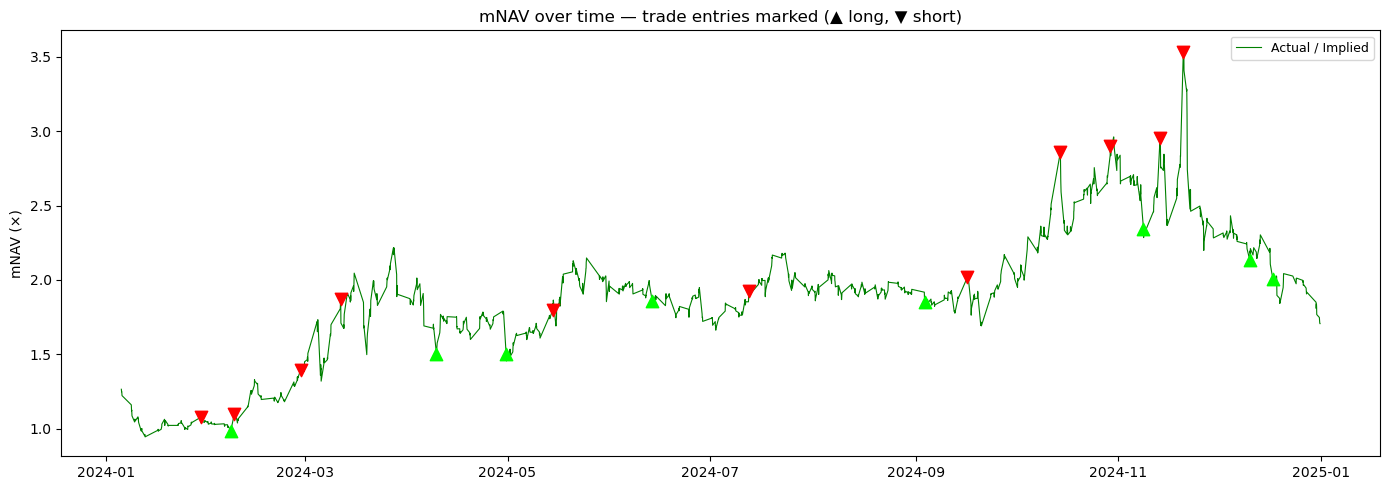

In [231]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(d.index, d['mnav'], lw=0.8, color='green', label='Actual / Implied')

# Mark long entries and short entries
for _, trade in trade_df.iterrows():
    color = 'lime' if trade['direction'] == 'long' else 'red'
    marker = '^' if trade['direction'] == 'long' else 'v'
    ax.scatter(trade['entry_time'], d.loc[d.index.asof(trade['entry_time']), 'mnav'],
               color=color, marker=marker, s=80, zorder=5)

ax.set_title('mNAV over time — trade entries marked (▲ long, ▼ short)')
ax.set_ylabel('mNAV (×)')
ax.legend(fontsize=9)
plt.tight_layout()

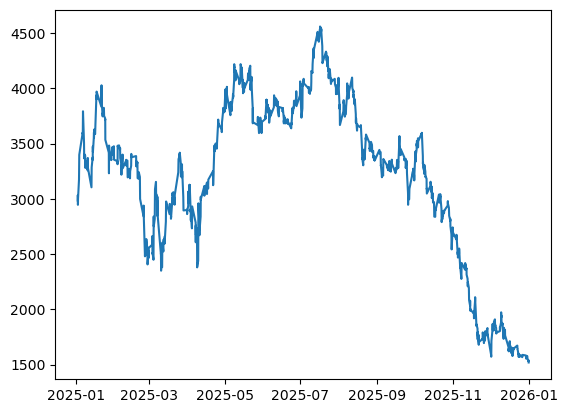

In [210]:
btc_raw      = pd.read_csv('btc_hourlyfinal.csv',       parse_dates=['date'])
mstr_raw     = pd.read_csv('mstr_hourlyfinal.csv',      parse_dates=['date'])
# After loading mstr_raw, before merging
SPLIT_DATE = '2025-01-01'
mstr_raw.loc[mstr_raw['date'] >= SPLIT_DATE, 'mstr'] *= 10
plt.plot(mstr_raw['date'], mstr_raw['mstr'], label='MSTR')